In [ ]:
print("hello")

hello


In [ ]:
import os

import sys

from pathlib import Path





def find_neqsim_project_root():

    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")

    candidates = []

    if env_root:

        candidates.append(Path(env_root).resolve())

    cwd = Path.cwd().resolve()

    candidates.extend([cwd] + list(cwd.parents))

    for candidate in candidates:

        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():

            return candidate

    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")





PROJECT_ROOT = find_neqsim_project_root()

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))



from neqsim_dev_setup import neqsim_classes, neqsim_init



ns = neqsim_init(project_root=PROJECT_ROOT, recompile=True, verbose=False)

if ns is None:

    raise RuntimeError("Kernel is restarting to load freshly compiled NeqSim classes. Rerun this cell after the restart.")

ns = neqsim_classes(ns)

try:

    SystemVanLaarActivitySRK = ns.JClass("neqsim.thermo.system.SystemVanLaarActivitySRK")

except TypeError as exc:

    if "SystemVanLaarActivitySRK" in str(exc) and "not found" in str(exc):

        print("JVM was started without the workspace NeqSim classes. Compiling and restarting the kernel...")

        neqsim_init(project_root=PROJECT_ROOT, recompile=True, verbose=True)

        raise RuntimeError("Kernel restart requested. Rerun this cell after the restart.")

    raise

ThermodynamicOperations = ns.ThermodynamicOperations



from neqsim.thermo.thermoTools import printFrame



Compiling... OK
All NeqSim classes imported OK


In [ ]:
system = SystemVanLaarActivitySRK(273.15 + (20), (100))
system.addComponent("CO2", float(1e6))
system.addComponent("water", 00)
system.addComponent("nitric acid", 10000)
system.addComponent("sulfuric acid",0)
system.createDatabase(True)
system.setMixingRule("classic")
ThermodynamicOperations(system).TPflash()
system.init(1)
system.initProperties()

printFrame(system)


TPflash VanLaar K outer=0 inner=1 beta=0.9989329039317981 deviation=43.424939761466334: CO2=6.037061587131286E14, water=4.356411041593375E-6, nitric acid=4.2069305252982627E-5, sulfuric acid=1.5609336987381434E-15
TPflash VanLaar K outer=0 inner=2 beta=0.999148808751793 deviation=32.56712895958833: CO2=1.4840107333931716E14, water=3.878198003065645E-6, nitric acid=2.6079880833127623E-4, sulfuric acid=1.8927264778992348E-13
TPflash VanLaar K outer=0 inner=3 beta=0.9998500594374543 deviation=24.411399085842806: CO2=5.180784913882945E13, water=3.568205140812232E-6, nitric acid=0.0010254684152227282, sulfuric acid=6.9132698287357375E-12
TPflash VanLaar K outer=0 inner=4 beta=0.9999874618491461 deviation=17.925354444049756: CO2=2.352955475950442E13, water=3.6293065773581265E-6, nitric acid=0.0028626997639799967, sulfuric acid=9.77000824435569E-11
TPflash VanLaar K outer=0 inner=5 beta=0.9999943255709216 deviation=8.340782800498735: CO2=1.3017484682642988E13, water=8.422264596313249E-6, nitr

In [5]:

printFrame(system)



components = [

    system.getPhase(0).getComponent(i).getComponentName()

    for i in range(system.getPhase(0).getNumberOfComponents())

]



phase_beta_limit = 1.0e-10

material_phases = []

print(f"\nMaterial phase wt% from flashed TPflash state (beta > {phase_beta_limit:g})")

for phase_index in range(system.getNumberOfPhases()):

    phase = system.getPhase(phase_index)

    beta = system.getBeta(phase_index)

    if beta <= phase_beta_limit:

        print(f"\n{phase.getPhaseTypeName()} phase is numerical trace only, beta={beta:.16e}; wt% is not material.")

        continue



    material_phases.append((phase_index, phase, beta))

    total_mass = sum(

        phase.getComponent(name).getx() * phase.getComponent(name).getMolarMass()

        for name in components

    )

    print(f"\n{phase.getPhaseTypeName()} phase, beta={beta:.16e}")

    for name in components:

        component = phase.getComponent(name)

        wt_percent = 100.0 * component.getx() * component.getMolarMass() / total_mass

        print(

            f"  {name}: x={component.getx():.6g}, "

            f"moles={component.getNumberOfMolesInPhase():.6g}, wt%={wt_percent:.6g}"

        )



print("\nComponent fugacities in material TPflash phases")

phase_fugacity_data = {}

for phase_index, phase, beta in material_phases:

    phase_fugacity_data[phase_index] = {}

    print(f"\n{phase.getPhaseTypeName()} phase #{phase_index}, beta={beta:.16e}")

    for name in components:

        component = phase.getComponent(name)

        component.fugcoef(phase)

        fugacity_bar = component.getx() * component.getFugacityCoefficient() * phase.getPressure()

        phase_fugacity_data[phase_index][name] = {

            "x": component.getx(),

            "phi": component.getFugacityCoefficient(),

            "fugacity_bar": fugacity_bar,

        }

        print(

            f"  {name}: x={component.getx():.6g}, "

            f"phi={component.getFugacityCoefficient():.6g}, fugacity={fugacity_bar:.6g} bara"

        )



def find_phase_by_name(fragment):

    for phase_index, phase, beta in material_phases:

        if fragment.lower() in phase.getPhaseTypeName().lower():

            return phase_index, phase, beta

    return None



gas_phase_tuple = find_phase_by_name("gas")

aqueous_phase_tuple = find_phase_by_name("aqueous")

if gas_phase_tuple is not None and aqueous_phase_tuple is not None:

    gas_phase_index, gas_phase, gas_beta = gas_phase_tuple

    aqueous_phase_index, aqueous_phase, aqueous_beta = aqueous_phase_tuple

    print("\nGas-aqueous fugacity and K-value check")

    print(

        f"gas phase #{gas_phase_index}, beta={gas_beta:.16e}; "

        f"aqueous phase #{aqueous_phase_index}, beta={aqueous_beta:.16e}"

)

    for name in components:

        gas_component = gas_phase.getComponent(name)

        aqueous_component = aqueous_phase.getComponent(name)

        gas_component.fugcoef(gas_phase)

        aqueous_component.fugcoef(aqueous_phase)

        gas_x = gas_component.getx()

        aqueous_x = aqueous_component.getx()

        gas_phi = gas_component.getFugacityCoefficient()

        aqueous_phi = aqueous_component.getFugacityCoefficient()

        gas_fugacity = gas_x * gas_phi * gas_phase.getPressure()

        aqueous_fugacity = aqueous_x * aqueous_phi * aqueous_phase.getPressure()

        k_composition = gas_x / aqueous_x if aqueous_x > 0.0 else float("inf")

        k_phi = aqueous_phi / gas_phi if gas_phi > 0.0 else float("inf")

        fugacity_ratio = gas_fugacity / aqueous_fugacity if aqueous_fugacity > 0.0 else float("inf")

        reconstructed_z = gas_beta * gas_x + aqueous_beta * aqueous_x

        feed_z = system.getPhase(0).getComponent(name).getz()

        print(

            f"  {name}: f_gas={gas_fugacity:.6g} bara, "

            f"f_aq={aqueous_fugacity:.6g} bara, f_gas/f_aq={fugacity_ratio:.6g}, "

            f"K_yx={k_composition:.6g}, K_phi={k_phi:.6g}, "

            f"z_feed={feed_z:.6g}, z_reconstructed={reconstructed_z:.6g}, "

            f"dz={reconstructed_z - feed_z:.3g}"

)

else:

    print("\nGas-aqueous fugacity and K-value check skipped: both material phases are not present.")



def find_vanlaar_liquid_phase(fluid):

    for candidate_phase_index in range(fluid.getNumberOfPhases()):

        candidate_phase = fluid.getPhase(candidate_phase_index)

        phase_name = candidate_phase.getPhaseTypeName().lower()

        class_name = str(candidate_phase.getClass().getSimpleName()).lower()

        if "aqueous" in phase_name or "liquid" in phase_name or "vanlaar" in class_name:

            return candidate_phase_index, candidate_phase

    raise RuntimeError("No VanLaar liquid phase available for the diagnostic liquid candidate.")



print("\nVanLaar liquid-candidate composition, activity, and fugacity")

liquid_candidate = SystemVanLaarActivitySRK(system.getTemperature(), system.getPressure())

liquid_candidate.addComponent("CO2", 1.0e-30)

for name in ["water", "nitric acid", "sulfuric acid"]:

    total_moles = system.getPhase(0).getComponent(name).getNumberOfmoles()

    liquid_candidate.addComponent(name, max(total_moles, 1.0e-30))

liquid_candidate.createDatabase(True)

liquid_candidate.setMixingRule("classic")

liquid_candidate.init(0)

liquid_candidate.init(1)

liquid_phase_index, liquid_phase = find_vanlaar_liquid_phase(liquid_candidate)

liquid_components = [

    liquid_phase.getComponent(i).getComponentName()

    for i in range(liquid_phase.getNumberOfComponents())

]

liquid_total_mass = sum(

    liquid_phase.getComponent(name).getx() * liquid_phase.getComponent(name).getMolarMass()

    for name in liquid_components

)

print(

    f"\nCandidate phase #{liquid_phase_index}: {liquid_phase.getPhaseTypeName()} "

    f"at T={liquid_phase.getTemperature() - 273.15:.3f} C, P={liquid_phase.getPressure():.6g} bara"

)

for name in liquid_components:

    component = liquid_phase.getComponent(name)

    component.fugcoef(liquid_phase)

    fugacity_bar = component.getx() * component.getFugacityCoefficient() * liquid_phase.getPressure()

    if name in ["water", "nitric acid", "sulfuric acid"]:

        gamma_x = liquid_phase.getActivityCoefficient(component.getComponentNumber())

        activity_x = component.getx() * gamma_x

    else:

        gamma_x = float("nan")

        activity_x = float("nan")

    wt_percent = 100.0 * component.getx() * component.getMolarMass() / liquid_total_mass

    print(

        f"  {name}: x={component.getx():.6g}, wt%={wt_percent:.6g}, "

        f"gamma_x={gamma_x:.6g}, activity_x={activity_x:.6g}, "

        f"phi={component.getFugacityCoefficient():.6g}, fugacity={fugacity_bar:.6g} bara"

)

                       0           1                      2  \
0                              total                    GAS   
1                    CO2  9.98891E-1             9.98891E-1   
2                  water  9.98891E-6             9.98891E-6   
3            nitric acid  1.09878E-3             1.09878E-3   
4          sulfuric acid         0E0                    0E0   
5                                                             
6                Density                          7.89884E2   
7         Phase Fraction                                1E0   
8             Molar Mass  4.40306E-2             4.40306E-2   
9               Z factor                         2.28701E-1   
10    Heat Capacity (Cp)                           2.9655E0   
11    Heat Capacity (Cv)                         9.43235E-1   
12        Speed of Sound                          4.37026E2   
13              Enthalpy   -2.4007E5              -2.4007E5   
14               Entropy  -1.53237E3             -1.532

Saved examples/notebooks/hno3_water_experiment_only_in_co2.png
Saved examples/notebooks/hno3_experiment_temperature_lines_100bar_20bar.png


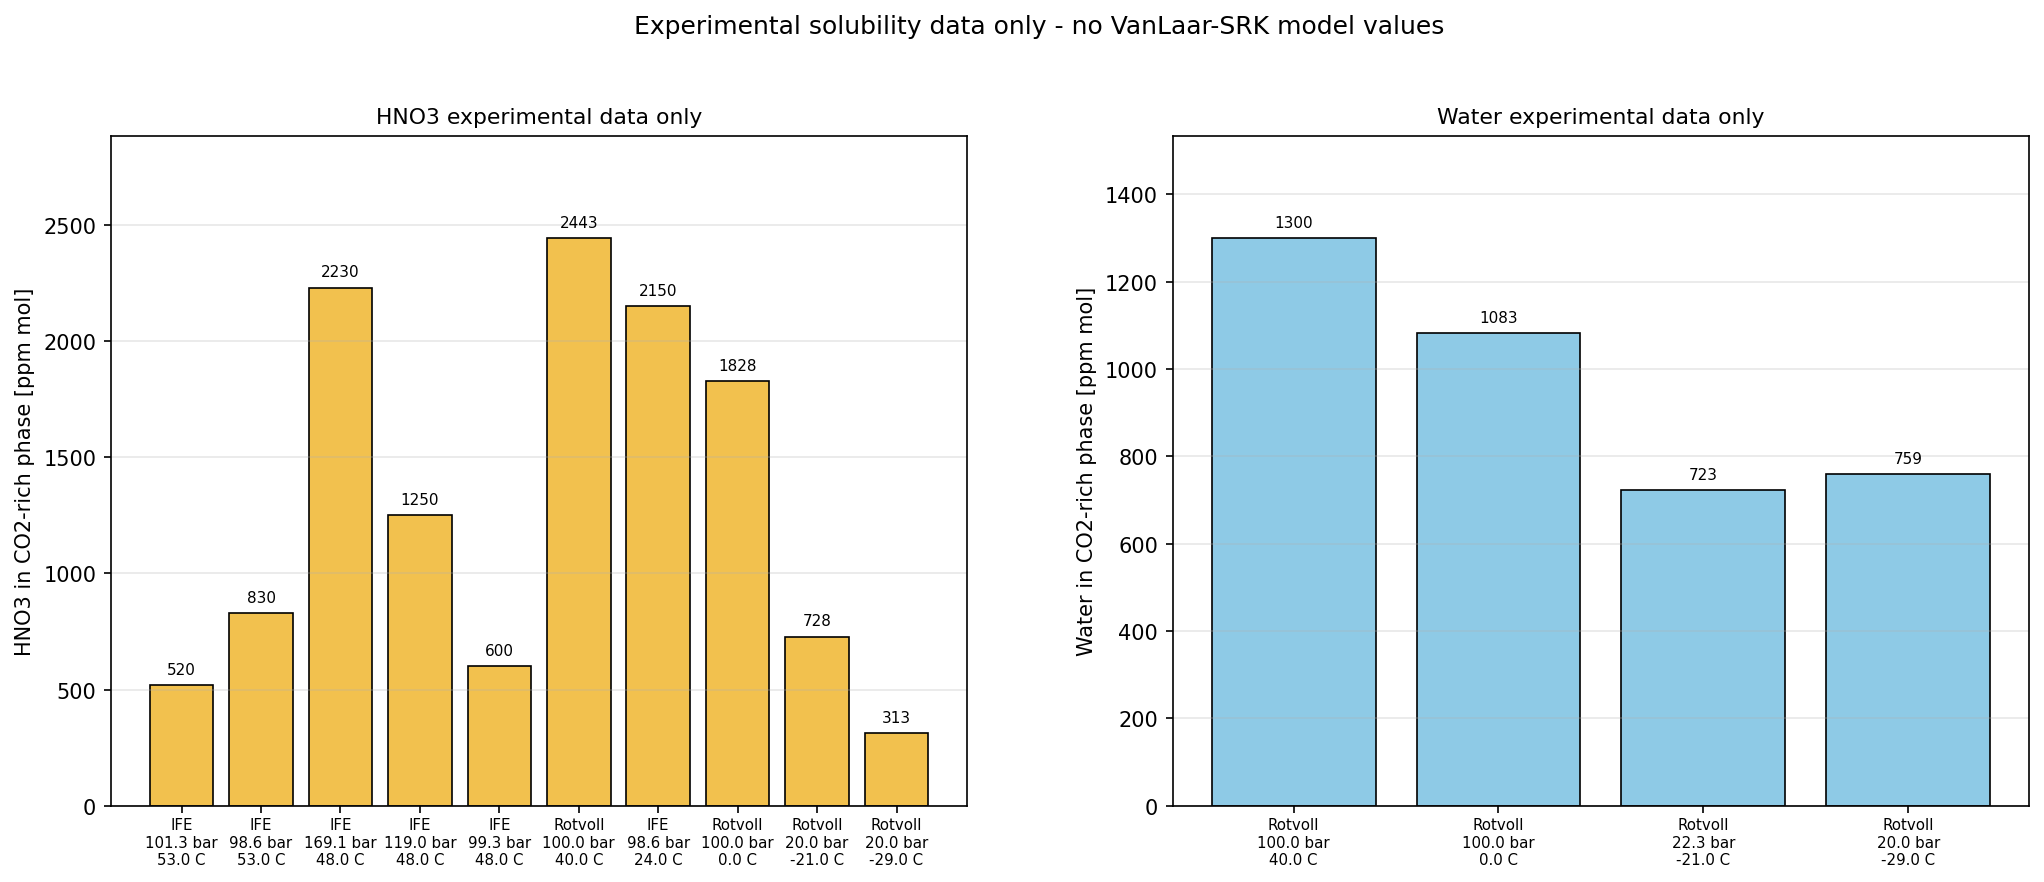

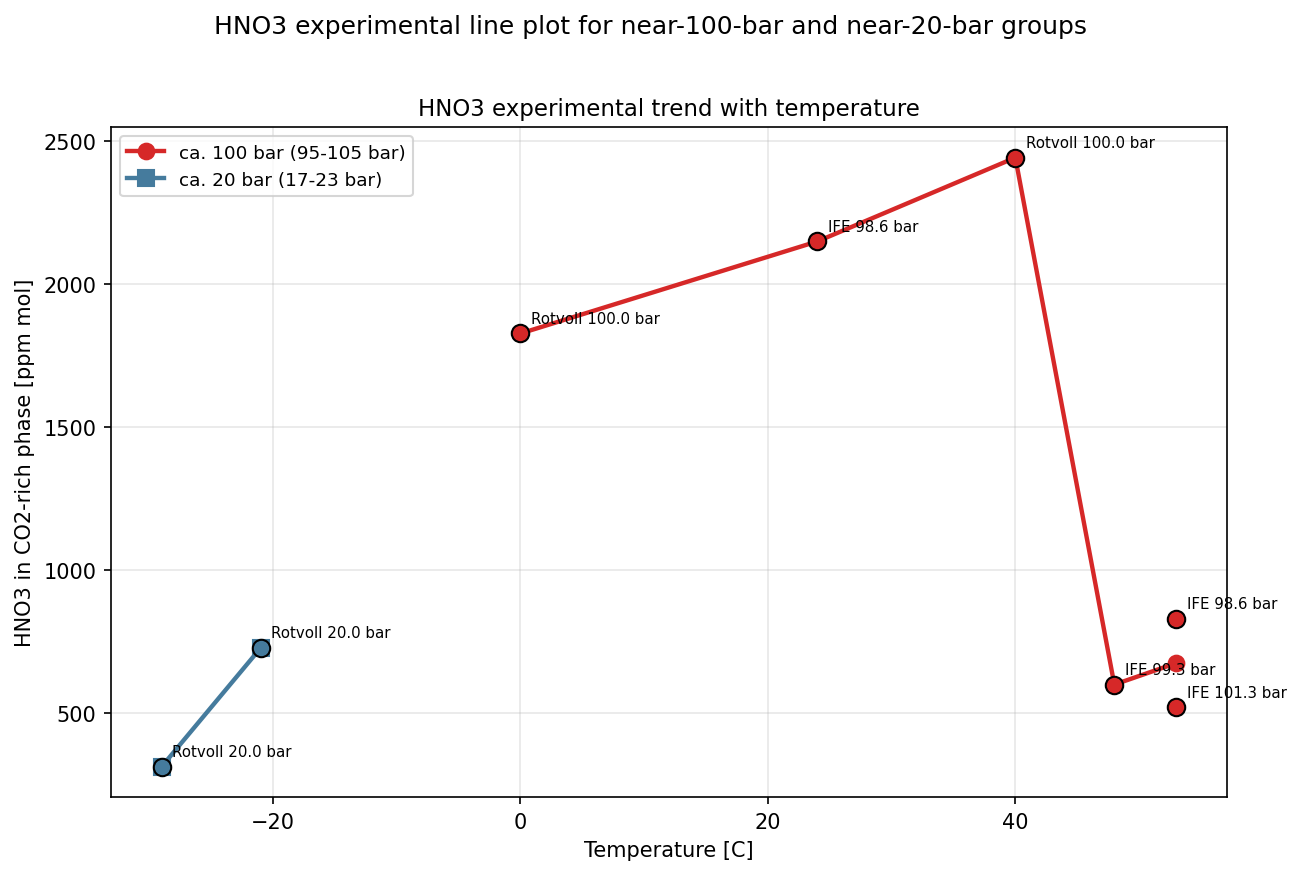

### HNO3 experimental rows used

| Source | P [bar] | T [C] | Experiment [ppm mol] |
|---|---:|---:|---:|
| IFE | 101.30 | 53.00 | 520.0 |
| IFE | 98.60 | 53.00 | 830.0 |
| IFE | 169.10 | 48.00 | 2230.0 |
| IFE | 119.00 | 48.00 | 1250.0 |
| IFE | 99.30 | 48.00 | 600.0 |
| Rotvoll | 100.00 | 40.00 | 2443.0 |
| IFE | 98.60 | 24.00 | 2150.0 |
| Rotvoll | 100.00 | 0.00 | 1828.0 |
| Rotvoll | 20.00 | -21.00 | 728.0 |
| Rotvoll | 20.00 | -29.00 | 313.0 |

### HNO3 rows in ca. 100 bar line

| Source | P [bar] | T [C] | Experiment [ppm mol] |
|---|---:|---:|---:|
| Rotvoll | 100.00 | 0.00 | 1828.0 |
| IFE | 98.60 | 24.00 | 2150.0 |
| Rotvoll | 100.00 | 40.00 | 2443.0 |
| IFE | 99.30 | 48.00 | 600.0 |
| IFE | 101.30 | 53.00 | 520.0 |
| IFE | 98.60 | 53.00 | 830.0 |

### HNO3 rows in ca. 20 bar line

| Source | P [bar] | T [C] | Experiment [ppm mol] |
|---|---:|---:|---:|
| Rotvoll | 20.00 | -29.00 | 313.0 |
| Rotvoll | 20.00 | -21.00 | 728.0 |

In [6]:
# Experiment-only HNO3/water plots and HNO3 temperature trends near 100 bar and 20 bar.
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display


if "PROJECT_ROOT" not in globals():
    def find_neqsim_project_root():
        env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
        candidates = []
        if env_root:
            candidates.append(Path(env_root).resolve())
        cwd = Path.cwd().resolve()
        candidates.extend([cwd] + list(cwd.parents))
        for candidate in candidates:
            if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
                return candidate
        raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")

    PROJECT_ROOT = find_neqsim_project_root()

EXPERIMENT_ONLY_OUTPUT_PNG = PROJECT_ROOT / "examples" / "notebooks" / "hno3_water_experiment_only_in_co2.png"
HNO3_TEMPERATURE_LINE_OUTPUT_PNG = PROJECT_ROOT / "examples" / "notebooks" / "hno3_experiment_temperature_lines_100bar_20bar.png"

EXPERIMENT_ONLY_HNO3_DATA = [
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 40.0, "experiment_ppm": 2443.0},
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 0.0, "experiment_ppm": 1828.0},
    {"source": "IFE", "pressure_bar": 98.6, "temperature_c": 24.0, "experiment_ppm": 2150.0},
    {"source": "IFE", "pressure_bar": 98.6, "temperature_c": 53.0, "experiment_ppm": 830.0},
    {"source": "IFE", "pressure_bar": 101.3, "temperature_c": 53.0, "experiment_ppm": 520.0},
    {"source": "IFE", "pressure_bar": 99.3, "temperature_c": 48.0, "experiment_ppm": 600.0},
    {"source": "IFE", "pressure_bar": 119.0, "temperature_c": 48.0, "experiment_ppm": 1250.0},
    {"source": "IFE", "pressure_bar": 169.1, "temperature_c": 48.0, "experiment_ppm": 2230.0},
    {"source": "Rotvoll", "pressure_bar": 20.0, "temperature_c": -21.0, "experiment_ppm": 728.0},
    {"source": "Rotvoll", "pressure_bar": 20.0, "temperature_c": -29.0, "experiment_ppm": 313.0},
]

EXPERIMENT_ONLY_WATER_DATA = [
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 40.0, "experiment_ppm": 1300.0},
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 0.0, "experiment_ppm": 1083.0},
    {"source": "Rotvoll", "pressure_bar": 22.3, "temperature_c": -21.0, "experiment_ppm": 723.0},
    {"source": "Rotvoll", "pressure_bar": 20.0, "temperature_c": -29.0, "experiment_ppm": 759.0},
]


def sort_experiment_rows(rows):
    return sorted(rows, key=lambda row: (-row["temperature_c"], -row["pressure_bar"]))


EXPERIMENT_ONLY_HNO3_DATA = sort_experiment_rows(EXPERIMENT_ONLY_HNO3_DATA)
EXPERIMENT_ONLY_WATER_DATA = sort_experiment_rows(EXPERIMENT_ONLY_WATER_DATA)


def condition_label(row):
    return f"{row['source']}\n{row['pressure_bar']:.1f} bar\n{row['temperature_c']:.1f} C"


def add_value_labels(axis, bars):
    y_min, y_max = axis.get_ylim()
    label_offset = (y_max - y_min) * 0.012
    for bar in bars:
        height = bar.get_height()
        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + label_offset,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=7.3,
        )


def add_experiment_bar_plot(axis, rows, ylabel, title, color):
    x_positions = np.arange(len(rows))
    values = np.array([row["experiment_ppm"] for row in rows], dtype=float)
    bars = axis.bar(
        x_positions,
        values,
        color=color,
        edgecolor="black",
        linewidth=0.8,
    )
    axis.set_title(title, fontsize=10.5)
    axis.set_ylabel(ylabel)
    axis.set_xticks(x_positions)
    axis.set_xticklabels([condition_label(row) for row in rows], fontsize=7.2)
    axis.tick_params(axis="x", pad=2)
    axis.grid(True, axis="y", alpha=0.3)
    axis.set_ylim(0.0, np.max(values) * 1.18)
    add_value_labels(axis, bars)


fig, (axis_hno3, axis_water) = plt.subplots(1, 2, figsize=(16.5, 5.8))
fig.subplots_adjust(wspace=0.24)
add_experiment_bar_plot(
    axis_hno3,
    EXPERIMENT_ONLY_HNO3_DATA,
    "HNO3 in CO2-rich phase [ppm mol]",
    "HNO3 experimental data only",
    "#f2c14e",
)
add_experiment_bar_plot(
    axis_water,
    EXPERIMENT_ONLY_WATER_DATA,
    "Water in CO2-rich phase [ppm mol]",
    "Water experimental data only",
    "#8ecae6",
)
fig.suptitle("Experimental solubility data only - no VanLaar-SRK model values", fontsize=12, y=1.02)
fig.savefig(EXPERIMENT_ONLY_OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)


def pressure_group_rows(rows, target_pressure_bar, tolerance_bar):
    return sorted(
        [
            row for row in rows
            if abs(row["pressure_bar"] - target_pressure_bar) <= tolerance_bar
        ],
        key=lambda row: row["temperature_c"],
    )


def average_by_temperature(rows):
    temperatures = sorted({row["temperature_c"] for row in rows})
    averaged = []
    for temperature_c in temperatures:
        matching = [row for row in rows if row["temperature_c"] == temperature_c]
        averaged.append({
            "temperature_c": temperature_c,
            "mean_ppm": float(np.mean([row["experiment_ppm"] for row in matching])),
            "min_ppm": float(np.min([row["experiment_ppm"] for row in matching])),
            "max_ppm": float(np.max([row["experiment_ppm"] for row in matching])),
            "count": len(matching),
        })
    return averaged


HNO3_NEAR_100_BAR_ROWS = pressure_group_rows(EXPERIMENT_ONLY_HNO3_DATA, 100.0, 5.0)
HNO3_NEAR_20_BAR_ROWS = pressure_group_rows(EXPERIMENT_ONLY_HNO3_DATA, 20.0, 3.0)

fig, axis = plt.subplots(figsize=(9.6, 5.8))
for rows, label, color, marker in [
    (HNO3_NEAR_100_BAR_ROWS, "ca. 100 bar (95-105 bar)", "#d62828", "o"),
    (HNO3_NEAR_20_BAR_ROWS, "ca. 20 bar (17-23 bar)", "#457b9d", "s"),
]:
    averaged_rows = average_by_temperature(rows)
    temperatures = np.array([row["temperature_c"] for row in averaged_rows], dtype=float)
    mean_ppm = np.array([row["mean_ppm"] for row in averaged_rows], dtype=float)
    axis.plot(
        temperatures,
        mean_ppm,
        color=color,
        marker=marker,
        linewidth=2.1,
        markersize=7.5,
        label=label,
    )
    axis.scatter(
        [row["temperature_c"] for row in rows],
        [row["experiment_ppm"] for row in rows],
        color=color,
        edgecolor="black",
        s=70,
        zorder=4,
    )
    for row in rows:
        axis.annotate(
            f"{row['source']} {row['pressure_bar']:.1f} bar",
            (row["temperature_c"], row["experiment_ppm"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=7.2,
        )

axis.set_title("HNO3 experimental trend with temperature", fontsize=11)
axis.set_xlabel("Temperature [C]")
axis.set_ylabel("HNO3 in CO2-rich phase [ppm mol]")
axis.grid(True, alpha=0.3)
axis.legend(fontsize=8.8)
fig.suptitle("HNO3 experimental line plot for near-100-bar and near-20-bar groups", fontsize=12, y=1.01)
fig.savefig(HNO3_TEMPERATURE_LINE_OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)


def experiment_markdown_table(title, rows):
    lines = [
        f"### {title}",
        "",
        "| Source | P [bar] | T [C] | Experiment [ppm mol] |",
        "|---|---:|---:|---:|",
    ]
    for row in rows:
        lines.append(
            f"| {row['source']} | {row['pressure_bar']:.2f} | "
            f"{row['temperature_c']:.2f} | {row['experiment_ppm']:.1f} |"
        )
    return "\n".join(lines)


print(f"Saved {EXPERIMENT_ONLY_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
print(f"Saved {HNO3_TEMPERATURE_LINE_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(EXPERIMENT_ONLY_OUTPUT_PNG)))
display(Image(filename=str(HNO3_TEMPERATURE_LINE_OUTPUT_PNG)))
display(Markdown(experiment_markdown_table("HNO3 experimental rows used", EXPERIMENT_ONLY_HNO3_DATA)))
display(Markdown(experiment_markdown_table("HNO3 rows in ca. 100 bar line", HNO3_NEAR_100_BAR_ROWS)))
display(Markdown(experiment_markdown_table("HNO3 rows in ca. 20 bar line", HNO3_NEAR_20_BAR_ROWS)))

In [ ]:
# OLI reference comparison against experimental HNO3 65 wt% solubility in CO2.
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display


if "PROJECT_ROOT" not in globals():
    def find_neqsim_project_root():
        env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
        candidates = []
        if env_root:
            candidates.append(Path(env_root).resolve())
        cwd = Path.cwd().resolve()
        candidates.extend([cwd] + list(cwd.parents))
        for candidate in candidates:
            if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
                return candidate
        raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")

    PROJECT_ROOT = find_neqsim_project_root()

OLI_EXPERIMENT_OUTPUT_PNG = PROJECT_ROOT / "examples" / "notebooks" / "oli_hno3_water_experiment_comparison.png"

OLI_VS_EXPERIMENT_DATA = [
    {
        "component": "HNO3",
        "source": "Rotvoll",
        "oli_pressure_bar": 100.0,
        "experiment_pressure_bar": 100.0,
        "temperature_c": 40.0,
        "oli_ppm": 462.0,
        "experiment_ppm": 2443.0,
        "notes": "Exact P/T match",
    },
    {
        "component": "HNO3",
        "source": "Rotvoll",
        "oli_pressure_bar": 100.0,
        "experiment_pressure_bar": 100.0,
        "temperature_c": 0.0,
        "oli_ppm": 514.0,
        "experiment_ppm": 1828.0,
        "notes": "Exact P/T match",
    },
    {
        "component": "HNO3",
        "source": "Rotvoll",
        "oli_pressure_bar": 20.0,
        "experiment_pressure_bar": 20.0,
        "temperature_c": -21.0,
        "oli_ppm": 236.0,
        "experiment_ppm": 728.0,
        "notes": "Low-temperature data point",
    },
    {
        "component": "HNO3",
        "source": "Rotvoll",
        "oli_pressure_bar": 20.0,
        "experiment_pressure_bar": 20.0,
        "temperature_c": -29.0,
        "oli_ppm": 247.0,
        "experiment_ppm": 313.0,
        "notes": "Low-temperature data point",
    },
    {
        "component": "Water",
        "source": "Rotvoll",
        "oli_pressure_bar": 100.0,
        "experiment_pressure_bar": 100.0,
        "temperature_c": 40.0,
        "oli_ppm": 1170.0,
        "experiment_ppm": 1300.0,
        "notes": "Exact P/T match",
    },
    {
        "component": "Water",
        "source": "Rotvoll",
        "oli_pressure_bar": 100.0,
        "experiment_pressure_bar": 100.0,
        "temperature_c": 0.0,
        "oli_ppm": 463.0,
        "experiment_ppm": 1083.0,
        "notes": "Exact P/T match",
    },
    {
        "component": "Water",
        "source": "Rotvoll",
        "oli_pressure_bar": 20.0,
        "experiment_pressure_bar": 22.3,
        "temperature_c": -21.0,
        "oli_ppm": 327.0,
        "experiment_ppm": 723.0,
        "notes": "Experiment at 22.3 bar; nearest OLI row at 20 bar",
    },
    {
        "component": "Water",
        "source": "Rotvoll",
        "oli_pressure_bar": 20.0,
        "experiment_pressure_bar": 20.0,
        "temperature_c": -29.0,
        "oli_ppm": 253.0,
        "experiment_ppm": 759.0,
        "notes": "Exact P/T match",
    },
]

OLI_ONLY_ROWS_WITHOUT_EXPERIMENT = [
    {"pressure_bar": 10.0, "temperature_c": -41.0, "oli_hno3_ppm": 169.0, "oli_water_ppm": 201.0, "solids": "HNO3.3H2O precipitates"},
    {"pressure_bar": 10.0, "temperature_c": -29.0, "oli_hno3_ppm": 5.4, "oli_water_ppm": 9.5, "solids": "HNO3.3H2O precipitates"},
]


def deviation_percent(model_value, reference_value):
    return (model_value / reference_value - 1.0) * 100.0


for row in OLI_VS_EXPERIMENT_DATA:
    row["oli_to_experiment_ratio"] = row["oli_ppm"] / row["experiment_ppm"]
    row["oli_deviation_pct"] = deviation_percent(row["oli_ppm"], row["experiment_ppm"])


def component_rows(component):
    return [row for row in OLI_VS_EXPERIMENT_DATA if row["component"] == component]


def condition_label(row):
    if row["oli_pressure_bar"] == row["experiment_pressure_bar"]:
        pressure_label = f"{row['oli_pressure_bar']:.0f} bar"
    else:
        pressure_label = f"OLI {row['oli_pressure_bar']:.0f} / exp {row['experiment_pressure_bar']:.1f} bar"
    return f"{pressure_label}\n{row['temperature_c']:.0f} C"


def mean_absolute_percent_error(rows):
    return float(np.mean([abs(row["oli_deviation_pct"]) for row in rows]))


def add_value_labels(axis, bars, offset):
    y_min, y_max = axis.get_ylim()
    label_offset = (y_max - y_min) * offset
    for bar in bars:
        height = bar.get_height()
        if np.isfinite(height):
            axis.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + label_offset,
                f"{height:.0f}",
                ha="center",
                va="bottom",
                fontsize=7.2,
            )


def add_oli_experiment_comparison(axis, rows, ylabel, title):
    labels = [condition_label(row) for row in rows]
    x_positions = np.arange(len(rows))
    width = 0.36
    experiment = np.array([row["experiment_ppm"] for row in rows], dtype=float)
    oli = np.array([row["oli_ppm"] for row in rows], dtype=float)

    experiment_bars = axis.bar(
        x_positions - width / 2.0,
        experiment,
        width,
        label="Experiment",
        color="#f2c14e",
        edgecolor="black",
        linewidth=0.8,
    )
    oli_bars = axis.bar(
        x_positions + width / 2.0,
        oli,
        width,
        label="OLI",
        color="#457b9d",
        edgecolor="black",
        linewidth=0.8,
    )

    axis.set_title(title, fontsize=10.5)
    axis.set_ylabel(ylabel)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(labels, fontsize=8.0)
    axis.tick_params(axis="x", pad=2)
    axis.grid(True, axis="y", alpha=0.3)
    axis.legend(fontsize=8.5)
    axis.set_ylim(0.0, max(np.max(experiment), np.max(oli)) * 1.24)
    add_value_labels(axis, experiment_bars, 0.012)
    add_value_labels(axis, oli_bars, 0.012)


def add_oli_deviation_plot(axis, rows, title):
    labels = [condition_label(row) for row in rows]
    deviations = np.array([row["oli_deviation_pct"] for row in rows], dtype=float)
    x_positions = np.arange(len(rows))
    colors = ["#d62828" if value > 0.0 else "#457b9d" for value in deviations]

    bars = axis.bar(x_positions, deviations, color=colors, edgecolor="black", linewidth=0.7)
    axis.axhline(0.0, color="0.2", linewidth=1.0)
    axis.set_title(title, fontsize=10.5)
    axis.set_ylabel("OLI deviation from experiment [%]")
    axis.set_xticks(x_positions)
    axis.set_xticklabels(labels, fontsize=8.0)
    axis.tick_params(axis="x", pad=2)
    axis.grid(True, axis="y", alpha=0.3)
    max_abs = max(20.0, np.max(np.abs(deviations)) * 1.18)
    axis.set_ylim(-max_abs, max_abs)

    for bar, deviation in zip(bars, deviations):
        y_text = deviation + (max_abs * 0.035 if deviation >= 0.0 else -max_abs * 0.055)
        va = "bottom" if deviation >= 0.0 else "top"
        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            y_text,
            f"{deviation:.0f}%",
            ha="center",
            va=va,
            fontsize=7.2,
        )


def oli_experiment_markdown_table(title, rows):
    lines = [
        f"### {title}",
        "",
        "| Source | OLI P [bar] | Exp P [bar] | T [C] | Experiment [ppm mol] | OLI [ppm mol] | OLI / exp | Deviation [%] | Notes |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---|",
    ]
    for row in rows:
        lines.append(
            f"| {row['source']} | {row['oli_pressure_bar']:.1f} | {row['experiment_pressure_bar']:.1f} | "
            f"{row['temperature_c']:.1f} | {row['experiment_ppm']:.1f} | {row['oli_ppm']:.1f} | "
            f"{row['oli_to_experiment_ratio']:.2f} | {row['oli_deviation_pct']:.1f} | {row['notes']} |"
        )
    return "\n".join(lines)


def oli_only_markdown_table(rows):
    lines = [
        "### OLI rows excluded from experiment comparison",
        "",
        "These OLI rows have no matching experimental value in the current dataset, so they are not included in the deviation or MAPE calculations.",
        "",
        "| P [bar] | T [C] | OLI HNO3 [ppm mol] | OLI water [ppm mol] | Solids |",
        "|---:|---:|---:|---:|---|",
    ]
    for row in rows:
        lines.append(
            f"| {row['pressure_bar']:.1f} | {row['temperature_c']:.1f} | "
            f"{row['oli_hno3_ppm']:.1f} | {row['oli_water_ppm']:.1f} | {row['solids']} |"
        )
    return "\n".join(lines)


hno3_rows = component_rows("HNO3")
water_rows = component_rows("Water")

fig, axes = plt.subplots(2, 2, figsize=(16.5, 8.4), gridspec_kw={"height_ratios": [2.0, 1.0]})
fig.subplots_adjust(wspace=0.26, hspace=0.42)

add_oli_experiment_comparison(
    axes[0, 0],
    hno3_rows,
    "HNO3 in CO2-rich phase [ppm mol]",
    "HNO3: experiment vs OLI",
)
add_oli_experiment_comparison(
    axes[0, 1],
    water_rows,
    "Water in CO2-rich phase [ppm mol]",
    "Water: experiment vs OLI",
)
add_oli_deviation_plot(axes[1, 0], hno3_rows, "HNO3 OLI deviation by condition")
add_oli_deviation_plot(axes[1, 1], water_rows, "Water OLI deviation by condition")

fig.suptitle(
    "OLI comparison against experimental HNO3 65 wt% source data\n"
    f"HNO3 MAPE={mean_absolute_percent_error(hno3_rows):.1f}%, "
    f"water MAPE={mean_absolute_percent_error(water_rows):.1f}%",
    fontsize=12,
    y=0.995,
)

fig.savefig(OLI_EXPERIMENT_OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {OLI_EXPERIMENT_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(OLI_EXPERIMENT_OUTPUT_PNG)))
display(Markdown(oli_experiment_markdown_table("HNO3 65 wt% acid in CO2 - OLI vs experiment", hno3_rows)))
display(Markdown(oli_experiment_markdown_table("Water from HNO3 65 wt% source in CO2 - OLI vs experiment", water_rows)))
display(Markdown(oli_only_markdown_table(OLI_ONLY_ROWS_WITHOUT_EXPERIMENT)))

In [ ]:
# OLI comparison against gasometer experiments for CO2 dissolved in the HNO3-rich acid phase.
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display


if "PROJECT_ROOT" not in globals():
    def find_neqsim_project_root():
        env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
        candidates = []
        if env_root:
            candidates.append(Path(env_root).resolve())
        cwd = Path.cwd().resolve()
        candidates.extend([cwd] + list(cwd.parents))
        for candidate in candidates:
            if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
                return candidate
        raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")

    PROJECT_ROOT = find_neqsim_project_root()

OLI_ACID_PHASE_OUTPUT_PNG = PROJECT_ROOT / "examples" / "notebooks" / "oli_co2_dissolved_in_hno3_experiment_comparison.png"

OLI_ACID_PHASE_DATA = [
    {"case": 1, "temperature_c": 40.0, "pressure_bar": 100.0, "oli_hno3_liquid1_wt_percent": 64.2, "oli_co2_liquid1_wt_percent": 1.25},
    {"case": 2, "temperature_c": 0.0, "pressure_bar": 100.0, "oli_hno3_liquid1_wt_percent": 64.1, "oli_co2_liquid1_wt_percent": 1.34},
    {"case": 3, "temperature_c": -21.0, "pressure_bar": 20.0, "oli_hno3_liquid1_wt_percent": 64.0, "oli_co2_liquid1_wt_percent": 1.57},
    {"case": 4, "temperature_c": -29.0, "pressure_bar": 20.0, "oli_hno3_liquid1_wt_percent": 64.7, "oli_co2_liquid1_wt_percent": 0.47},
    {"case": 5, "temperature_c": -41.0, "pressure_bar": 10.0, "oli_hno3_liquid1_wt_percent": 67.8, "oli_co2_liquid1_wt_percent": 4.72},
    {"case": 6, "temperature_c": -29.0, "pressure_bar": 10.0, "oli_hno3_liquid1_wt_percent": 65.8, "oli_co2_liquid1_wt_percent": 2.13},
]

CO2_IN_ACID_EXPERIMENTS = [
    {
        "experiment": "Forsok 3",
        "pressure_bar": 100.30,
        "temperature_c": 40.19,
        "hno3_mass_g": 27.6896,
        "gasometer_volume_ml": 964.15,
        "co2_mass_g": 1.746,
        "experiment_co2_hno3_wt_percent": 6.31,
    },
    {
        "experiment": "Forsok 7",
        "pressure_bar": 101.16,
        "temperature_c": 40.00,
        "hno3_mass_g": 36.3455,
        "gasometer_volume_ml": 1035.20,
        "co2_mass_g": 1.875,
        "experiment_co2_hno3_wt_percent": 5.16,
    },
    {
        "experiment": "Forsok 9",
        "pressure_bar": 100.45,
        "temperature_c": 0.02,
        "hno3_mass_g": 32.6832,
        "gasometer_volume_ml": 598.41,
        "co2_mass_g": 1.084,
        "experiment_co2_hno3_wt_percent": 3.32,
    },
]


def nearest_oli_acid_phase_row(experiment_row):
    def distance(oli_row):
        temperature_delta = abs(oli_row["temperature_c"] - experiment_row["temperature_c"])
        pressure_delta = abs(oli_row["pressure_bar"] - experiment_row["pressure_bar"])
        return temperature_delta + 0.05 * pressure_delta

    return min(OLI_ACID_PHASE_DATA, key=distance)


def deviation_percent(model_value, reference_value):
    return (model_value / reference_value - 1.0) * 100.0


for row in CO2_IN_ACID_EXPERIMENTS:
    oli_row = nearest_oli_acid_phase_row(row)
    row["oli_case"] = oli_row["case"]
    row["oli_pressure_bar"] = oli_row["pressure_bar"]
    row["oli_temperature_c"] = oli_row["temperature_c"]
    row["oli_hno3_liquid1_wt_percent"] = oli_row["oli_hno3_liquid1_wt_percent"]
    row["oli_co2_liquid1_wt_percent"] = oli_row["oli_co2_liquid1_wt_percent"]
    row["oli_to_experiment_ratio"] = row["oli_co2_liquid1_wt_percent"] / row["experiment_co2_hno3_wt_percent"]
    row["oli_deviation_pct"] = deviation_percent(
        row["oli_co2_liquid1_wt_percent"],
        row["experiment_co2_hno3_wt_percent"],
    )


def condition_label(row):
    return (
        f"{row['experiment']}\n"
        f"exp {row['temperature_c']:.2f} C, {row['pressure_bar']:.2f} bar\n"
        f"OLI {row['oli_temperature_c']:.0f} C, {row['oli_pressure_bar']:.0f} bar"
    )


def mean_absolute_percent_error(rows):
    return float(np.mean([abs(row["oli_deviation_pct"]) for row in rows]))


def add_value_labels(axis, bars, suffix, offset):
    y_min, y_max = axis.get_ylim()
    label_offset = (y_max - y_min) * offset
    for bar in bars:
        height = bar.get_height()
        if np.isfinite(height):
            axis.text(
                bar.get_x() + bar.get_width() / 2.0,
                height + label_offset,
                f"{height:.2f}{suffix}",
                ha="center",
                va="bottom",
                fontsize=8.0,
            )


def acid_phase_markdown_table(title, rows):
    lines = [
        f"### {title}",
        "",
        "| Experiment | Exp P [bar] | Exp T [C] | Gasometer V [ml] | m_CO2 [g] | Experiment CO2 in HNO3 [wt%] | OLI case | OLI P [bar] | OLI T [C] | OLI HNO3 in Liquid-1 [wt%] | OLI CO2 in Liquid-1 [wt%] | OLI / exp | Deviation [%] |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for row in rows:
        lines.append(
            f"| {row['experiment']} | {row['pressure_bar']:.2f} | {row['temperature_c']:.2f} | "
            f"{row['gasometer_volume_ml']:.2f} | {row['co2_mass_g']:.3f} | "
            f"{row['experiment_co2_hno3_wt_percent']:.2f} | {row['oli_case']} | "
            f"{row['oli_pressure_bar']:.1f} | {row['oli_temperature_c']:.1f} | "
            f"{row['oli_hno3_liquid1_wt_percent']:.1f} | {row['oli_co2_liquid1_wt_percent']:.2f} | "
            f"{row['oli_to_experiment_ratio']:.2f} | {row['oli_deviation_pct']:.1f} |"
        )
    return "\n".join(lines)


def oli_acid_phase_table(rows):
    lines = [
        "### OLI Liquid-1 acid-phase rows",
        "",
        "| # | T [C] | P [bar] | HNO3 in Liquid-1 [wt%] | CO2 in Liquid-1 [wt%] |",
        "|---:|---:|---:|---:|---:|",
    ]
    for row in rows:
        lines.append(
            f"| {row['case']} | {row['temperature_c']:.0f} | {row['pressure_bar']:.0f} | "
            f"{row['oli_hno3_liquid1_wt_percent']:.1f} | {row['oli_co2_liquid1_wt_percent']:.2f} |"
        )
    return "\n".join(lines)


labels = [condition_label(row) for row in CO2_IN_ACID_EXPERIMENTS]
x_positions = np.arange(len(CO2_IN_ACID_EXPERIMENTS))
width = 0.36
experiment_values = np.array([row["experiment_co2_hno3_wt_percent"] for row in CO2_IN_ACID_EXPERIMENTS], dtype=float)
oli_values = np.array([row["oli_co2_liquid1_wt_percent"] for row in CO2_IN_ACID_EXPERIMENTS], dtype=float)
deviations = np.array([row["oli_deviation_pct"] for row in CO2_IN_ACID_EXPERIMENTS], dtype=float)

fig, (ax_compare, ax_deviation) = plt.subplots(1, 2, figsize=(15.5, 5.7), gridspec_kw={"width_ratios": [1.35, 1.0]})
fig.subplots_adjust(wspace=0.30)

experiment_bars = ax_compare.bar(
    x_positions - width / 2.0,
    experiment_values,
    width,
    label="Gasometer experiment",
    color="#f2c14e",
    edgecolor="black",
    linewidth=0.8,
)
oli_bars = ax_compare.bar(
    x_positions + width / 2.0,
    oli_values,
    width,
    label="OLI Liquid-1",
    color="#457b9d",
    edgecolor="black",
    linewidth=0.8,
)
ax_compare.set_title("CO2 dissolved in HNO3 phase: experiment vs OLI", fontsize=10.5)
ax_compare.set_ylabel("CO2 in HNO3-rich phase [wt%]")
ax_compare.set_xticks(x_positions)
ax_compare.set_xticklabels(labels, fontsize=7.5)
ax_compare.grid(True, axis="y", alpha=0.3)
ax_compare.legend(fontsize=8.5)
ax_compare.set_ylim(0.0, max(np.max(experiment_values), np.max(oli_values)) * 1.20)
add_value_labels(ax_compare, experiment_bars, "", 0.012)
add_value_labels(ax_compare, oli_bars, "", 0.012)

colors = ["#d62828" if value > 0.0 else "#457b9d" for value in deviations]
deviation_bars = ax_deviation.bar(x_positions, deviations, color=colors, edgecolor="black", linewidth=0.7)
ax_deviation.axhline(0.0, color="0.2", linewidth=1.0)
ax_deviation.set_title("OLI deviation from gasometer experiment", fontsize=10.5)
ax_deviation.set_ylabel("Deviation [%]")
ax_deviation.set_xticks(x_positions)
ax_deviation.set_xticklabels([row["experiment"] for row in CO2_IN_ACID_EXPERIMENTS], fontsize=8.5)
ax_deviation.grid(True, axis="y", alpha=0.3)
max_abs = max(20.0, np.max(np.abs(deviations)) * 1.18)
ax_deviation.set_ylim(-max_abs, max_abs)
for bar, deviation in zip(deviation_bars, deviations):
    y_text = deviation + (max_abs * 0.035 if deviation >= 0.0 else -max_abs * 0.055)
    va = "bottom" if deviation >= 0.0 else "top"
    ax_deviation.text(
        bar.get_x() + bar.get_width() / 2.0,
        y_text,
        f"{deviation:.0f}%",
        ha="center",
        va=va,
        fontsize=8.0,
    )

fig.suptitle(
    "OLI comparison for CO2 dissolved in the HNO3-rich acid phase\n"
    f"Nearest OLI P/T row used for each experiment; MAPE={mean_absolute_percent_error(CO2_IN_ACID_EXPERIMENTS):.1f}%",
    fontsize=12,
    y=1.02,
)

fig.savefig(OLI_ACID_PHASE_OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {OLI_ACID_PHASE_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(OLI_ACID_PHASE_OUTPUT_PNG)))
display(Markdown(acid_phase_markdown_table("CO2 dissolved in HNO3 phase - OLI vs gasometer experiments", CO2_IN_ACID_EXPERIMENTS)))
display(Markdown(oli_acid_phase_table(OLI_ACID_PHASE_DATA)))

# TPflash-only VanLaar acid solubility and corrosion screening

This section uses `SystemVanLaarActivitySRK` and `ThermodynamicOperations.TPflash()` directly for every model point. The helper below iterates source inventory when a target gas-phase acid concentration is specified, then builds comparison plots against the IFE and Rotvoll data, P-T isolines for 65 wt% HNO3 and 98 wt% H2SO4 source liquids, HNO3/H2SO4 interaction plots, and a water-limit corrosion screening view.

In [ ]:
# TPflash-only VanLaar acid study: water-fixed source iteration, plots, and report text.
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_neqsim_project_root():
        env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
        candidates = []
        if env_root:
            candidates.append(Path(env_root).resolve())
        cwd = Path.cwd().resolve()
        candidates.extend([cwd] + list(cwd.parents))
        for candidate in candidates:
            if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
                return candidate
        raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")

    PROJECT_ROOT = find_neqsim_project_root()
    sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

if "SystemVanLaarActivitySRK" not in globals():
    from neqsim_dev_setup import neqsim_classes, neqsim_init

    ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
    ns = neqsim_classes(ns)
    SystemVanLaarActivitySRK = ns.JClass("neqsim.thermo.system.SystemVanLaarActivitySRK")
    ThermodynamicOperations = ns.ThermodynamicOperations

TRACE_MOLES = 1.0e-30
CO2_MOLES = 1.0e6
SOURCE_WATER_PPM = 1000.0
SOURCE_WATER_MOLES = CO2_MOLES * SOURCE_WATER_PPM / 1.0e6
MW_G_PER_MOL = {"water": 18.01528, "nitric acid": 63.01284, "sulfuric acid": 98.07848}
TARGET_AQUEOUS_ACID_WT = {"nitric acid": 65.0, "sulfuric acid": 98.0}
ACID_LABEL = {"nitric acid": "HNO3", "sulfuric acid": "H2SO4"}
FIGURE_DIR = PROJECT_ROOT / "examples" / "notebooks"

HNO3_EXPERIMENTS = [
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 0.0, "ppm": 1828.0},
    {"source": "Rotvoll", "pressure_bar": 100.0, "temperature_c": 40.0, "ppm": 2443.0},
    {"source": "IFE", "pressure_bar": 98.6, "temperature_c": 24.0, "ppm": 2150.0},
    {"source": "IFE", "pressure_bar": 98.6, "temperature_c": 53.0, "ppm": 830.0},
    {"source": "IFE", "pressure_bar": 101.3, "temperature_c": 53.0, "ppm": 520.0},
    {"source": "IFE", "pressure_bar": 99.3, "temperature_c": 48.0, "ppm": 600.0},
    {"source": "IFE", "pressure_bar": 119.0, "temperature_c": 48.0, "ppm": 1250.0},
    {"source": "IFE", "pressure_bar": 169.1, "temperature_c": 48.0, "ppm": 2230.0},
    {"source": "Ship transport", "pressure_bar": 20.0, "temperature_c": -21.0, "ppm": 723.0},
    {"source": "Ship transport", "pressure_bar": 20.0, "temperature_c": -29.0, "ppm": 313.0},
    {"source": "Ship transport", "pressure_bar": 23.56, "temperature_c": -19.19, "ppm": 787.5},
    {"source": "Ship transport", "pressure_bar": 22.86, "temperature_c": -17.92, "ppm": 896.4},
]
H2SO4_EXPERIMENTS = [
    {"source": "IFE", "pressure_bar": 94.6, "temperature_c": 25.0, "ppm": 2.26},
    {"source": "IFE", "pressure_bar": 77.9, "temperature_c": 46.5, "ppm": 0.06},
    {"source": "IFE", "pressure_bar": 98.4, "temperature_c": 47.2, "ppm": 1.18},
    {"source": "IFE", "pressure_bar": 118.6, "temperature_c": 47.9, "ppm": 2.40},
    {"source": "IFE", "pressure_bar": 168.7, "temperature_c": 48.4, "ppm": 7.70},
]


def error_result(message, temperature_c=None, pressure_bar=None):
    return {
        "status": "ERROR",
        "error": str(message),
        "temperature_c": float(temperature_c) if temperature_c is not None else np.nan,
        "pressure_bar": float(pressure_bar) if pressure_bar is not None else np.nan,
        "carrier_beta": np.nan,
        "aqueous_beta": np.nan,
        "gas_water_ppm": np.nan,
        "gas_hno3_ppm": np.nan,
        "gas_h2so4_ppm": np.nan,
        "aqueous_water_wt_pct": np.nan,
        "aqueous_hno3_wt_pct": np.nan,
        "aqueous_h2so4_wt_pct": np.nan,
        "aqueous_water_moles": np.nan,
        "aqueous_hno3_moles": np.nan,
        "aqueous_h2so4_moles": np.nan,
    }


def is_ok(result):
    return result.get("status", "OK") == "OK"


def phase_component_ppm(phase, component_name):
    if phase is None:
        return 0.0
    return float(phase.getComponent(component_name).getx()) * 1.0e6


def phase_component_moles(phase, component_name):
    if phase is None:
        return 0.0
    return float(phase.getComponent(component_name).getNumberOfMolesInPhase())


def phase_co2_moles(phase):
    return phase_component_moles(phase, "CO2")


def select_co2_phase(fluid):
    co2_phase_index = max(
        range(fluid.getNumberOfPhases()),
        key=lambda phase_index: phase_co2_moles(fluid.getPhase(phase_index)),
    )
    return fluid.getPhase(co2_phase_index), float(fluid.getBeta(co2_phase_index))


def select_acidic_phase(fluid):
    if fluid.getNumberOfPhases() < 2:
        return None, 0.0
    acid_phase_index = min(
        range(fluid.getNumberOfPhases()),
        key=lambda phase_index: phase_co2_moles(fluid.getPhase(phase_index)),
    )
    return fluid.getPhase(acid_phase_index), float(fluid.getBeta(acid_phase_index))


def aqueous_weight_percent(phase, component_name):
    if phase is None:
        return 0.0
    total_mass = 0.0
    component_mass = 0.0
    for name in ["CO2", "water", "nitric acid", "sulfuric acid"]:
        component = phase.getComponent(name)
        mass = float(component.getx()) * float(component.getMolarMass())
        total_mass += mass
        if name == component_name:
            component_mass = mass
    return 0.0 if total_mass <= 0.0 else 100.0 * component_mass / total_mass


def run_vanlaar_tpflash(temperature_c, pressure_bar, water_moles=SOURCE_WATER_MOLES,
                        nitric_acid_moles=TRACE_MOLES, sulfuric_acid_moles=TRACE_MOLES,
                        co2_moles=CO2_MOLES):
    fluid = SystemVanLaarActivitySRK(273.15 + float(temperature_c), float(pressure_bar))
    fluid.addComponent("CO2", float(co2_moles))
    fluid.addComponent("water", max(float(water_moles), TRACE_MOLES))
    fluid.addComponent("nitric acid", max(float(nitric_acid_moles), TRACE_MOLES))
    fluid.addComponent("sulfuric acid", max(float(sulfuric_acid_moles), TRACE_MOLES))
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    ThermodynamicOperations(fluid).TPflash()
    fluid.init(1)
    fluid.initProperties()

    carrier_phase, carrier_beta = select_co2_phase(fluid)
    aqueous_phase, aqueous_beta = select_acidic_phase(fluid)
    return {
        "status": "OK",
        "error": "",
        "fluid": fluid,
        "temperature_c": float(temperature_c),
        "pressure_bar": float(pressure_bar),
        "carrier_beta": carrier_beta,
        "aqueous_beta": aqueous_beta,
        "gas_water_ppm": phase_component_ppm(carrier_phase, "water"),
        "gas_hno3_ppm": phase_component_ppm(carrier_phase, "nitric acid"),
        "gas_h2so4_ppm": phase_component_ppm(carrier_phase, "sulfuric acid"),
        "aqueous_water_wt_pct": aqueous_weight_percent(aqueous_phase, "water"),
        "aqueous_hno3_wt_pct": aqueous_weight_percent(aqueous_phase, "nitric acid"),
        "aqueous_h2so4_wt_pct": aqueous_weight_percent(aqueous_phase, "sulfuric acid"),
        "aqueous_water_moles": phase_component_moles(aqueous_phase, "water"),
        "aqueous_hno3_moles": phase_component_moles(aqueous_phase, "nitric acid"),
        "aqueous_h2so4_moles": phase_component_moles(aqueous_phase, "sulfuric acid"),
    }


def safe_run_vanlaar_tpflash(*args, **kwargs):
    temperature_c = args[0] if len(args) > 0 else kwargs.get("temperature_c")
    pressure_bar = args[1] if len(args) > 1 else kwargs.get("pressure_bar")
    try:
        return run_vanlaar_tpflash(*args, **kwargs)
    except Exception as exc:
        return error_result(exc, temperature_c, pressure_bar)


def aqueous_acid_weight_percent(result, acid_name):
    if not is_ok(result):
        return np.nan
    return result["aqueous_hno3_wt_pct"] if acid_name == "nitric acid" else result["aqueous_h2so4_wt_pct"]


def initial_acid_guess_from_target(acid_name, water_moles=SOURCE_WATER_MOLES):
    target = TARGET_AQUEOUS_ACID_WT[acid_name]
    water_mass = water_moles * MW_G_PER_MOL["water"]
    acid_mass = water_mass * target / max(1.0e-12, 100.0 - target)
    return acid_mass / MW_G_PER_MOL[acid_name]


def run_source_tpflash(acid_name, temperature_c, pressure_bar, water_moles=SOURCE_WATER_MOLES,
                       target_wt=None, tolerance_wt=0.02, max_iterations=45):
    if target_wt is None:
        target_wt = TARGET_AQUEOUS_ACID_WT[acid_name]
    low = TRACE_MOLES
    high = max(10.0, initial_acid_guess_from_target(acid_name, water_moles) * 4.0)

    def flash_with_acid(acid_moles):
        return safe_run_vanlaar_tpflash(
            temperature_c,
            pressure_bar,
            water_moles=water_moles,
            nitric_acid_moles=acid_moles if acid_name == "nitric acid" else TRACE_MOLES,
            sulfuric_acid_moles=acid_moles if acid_name == "sulfuric acid" else TRACE_MOLES,
        )

    high_result = flash_with_acid(high)
    high_backoff_count = 0
    while not is_ok(high_result) and high > 1.0e-9 and high_backoff_count < 40:
        high *= 0.5
        high_result = flash_with_acid(high)
        high_backoff_count += 1
    if not is_ok(high_result):
        high_result["source_acid_moles"] = high
        high_result["target_aqueous_acid_wt_pct"] = target_wt
        high_result["actual_aqueous_acid_wt_pct"] = np.nan
        high_result["source_water_moles"] = water_moles
        return high_result

    expansion_count = 0
    bracket_limited = False
    last_error = ""
    while aqueous_acid_weight_percent(high_result, acid_name) < target_wt and expansion_count < 30:
        low = high
        trial_high = high * 2.0
        trial_result = flash_with_acid(trial_high)
        if not is_ok(trial_result):
            bracket_limited = True
            last_error = trial_result.get("error", "")
            break
        high = trial_high
        high_result = trial_result
        expansion_count += 1

    best_acid_moles = high
    best_result = high_result
    if bracket_limited:
        best_result["warning"] = (
            "Target acid wt% was not fully bracketed before TPflash failed at higher acid inventory: "
            + short_error(last_error, 160)
        )
    if is_ok(high_result):
        for _iteration in range(max_iterations):
            trial = 0.5 * (low + high)
            result = flash_with_acid(trial)
            if not is_ok(result):
                high = trial
                continue
            liquid_wt = aqueous_acid_weight_percent(result, acid_name)
            best_acid_moles = trial
            best_result = result
            if abs(liquid_wt - target_wt) <= tolerance_wt:
                break
            if liquid_wt < target_wt:
                low = trial
            else:
                high = trial

    best_result["source_acid_moles"] = best_acid_moles
    best_result["target_aqueous_acid_wt_pct"] = target_wt
    best_result["actual_aqueous_acid_wt_pct"] = aqueous_acid_weight_percent(best_result, acid_name)
    best_result["source_water_moles"] = water_moles
    return best_result


def gas_acid_ppm(result, acid_name):
    if not is_ok(result):
        return np.nan
    return result["gas_hno3_ppm"] if acid_name == "nitric acid" else result["gas_h2so4_ppm"]


def tune_source_inventory_for_gas_ppm(acid_name, target_ppm, temperature_c, pressure_bar,
                                      water_moles=SOURCE_WATER_MOLES,
                                      low_moles=1.0e-12, high_moles=1.0e5,
                                      tolerance_ppm=0.01, max_iterations=45):
    def flash_with_acid(acid_moles):
        return safe_run_vanlaar_tpflash(
            temperature_c,
            pressure_bar,
            water_moles=water_moles,
            nitric_acid_moles=acid_moles if acid_name == "nitric acid" else TRACE_MOLES,
            sulfuric_acid_moles=acid_moles if acid_name == "sulfuric acid" else TRACE_MOLES,
        )

    high_result = flash_with_acid(high_moles)
    if not is_ok(high_result):
        return high_moles, high_result, "error at upper bound"
    if gas_acid_ppm(high_result, acid_name) < target_ppm:
        return high_moles, high_result, "target above TPflash saturation at upper bound"

    low = low_moles
    high = high_moles
    best_result = high_result
    trial = high
    for _iteration in range(max_iterations):
        trial = math.sqrt(low * high)
        result = flash_with_acid(trial)
        if not is_ok(result):
            high = trial
            continue
        best_result = result
        error = gas_acid_ppm(result, acid_name) - target_ppm
        if abs(error) <= tolerance_ppm:
            return trial, result, "converged"
        if error < 0.0:
            low = trial
        else:
            high = trial
    return trial, best_result, "iteration limit reached"


def model_experiment_rows(acid_name, experiments):
    rows = []
    for row in experiments:
        result = run_source_tpflash(acid_name, row["temperature_c"], row["pressure_bar"])
        model_ppm = gas_acid_ppm(result, acid_name)
        rows.append({
            "source": row["source"],
            "pressure_bar": row["pressure_bar"],
            "temperature_c": row["temperature_c"],
            "experiment_ppm": row["ppm"],
            "tpflash_ppm": model_ppm,
            "deviation_pct": np.nan if not np.isfinite(model_ppm) else 100.0 * (model_ppm / row["ppm"] - 1.0),
            "source_acid_moles": result.get("source_acid_moles", np.nan),
            "actual_aqueous_acid_wt_pct": result.get("actual_aqueous_acid_wt_pct", np.nan),
            "status": result.get("status", "OK"),
            "error": result.get("error", ""),
        })
    return rows


def markdown_table(title, headers, rows):
    lines = [f"### {title}", "", "| " + " | ".join(headers) + " |", "|" + "|".join(["---" for _ in headers]) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


def format_float(value, digits=3):
    if value is None or not np.isfinite(value):
        return "ERROR"
    return f"{value:.{digits}g}"


def short_error(message, max_chars=80):
    if not message:
        return ""
    return str(message).replace("\n", " ")[:max_chars]


def experiment_table_rows_from_model_rows(rows):
    table_rows = []
    for row in rows:
        table_rows.append([
            row["source"],
            f"{row['pressure_bar']:.2f}",
            f"{row['temperature_c']:.2f}",
            format_float(row["experiment_ppm"], 4),
            format_float(row["tpflash_ppm"], 4),
            format_float(row["deviation_pct"], 3),
            format_float(row["actual_aqueous_acid_wt_pct"], 4),
            format_float(row["source_acid_moles"], 4),
            row.get("status", "OK"),
            short_error(row.get("error", "")),
        ])
    return table_rows


def finite_rows(rows):
    return [row for row in rows if row.get("status", "OK") == "OK" and np.isfinite(row.get("tpflash_ppm", np.nan))]

# 1) Experiment comparison from water-fixed, acid-strength-targeted TPflash calculations.
hno3_rows = model_experiment_rows("nitric acid", HNO3_EXPERIMENTS)
h2so4_rows = model_experiment_rows("sulfuric acid", H2SO4_EXPERIMENTS)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.0))
for axis, rows, acid_name, color in [
    (axes[0], hno3_rows, "nitric acid", "#2f6f9f"),
    (axes[1], h2so4_rows, "sulfuric acid", "#b23a48"),
]:
    good_rows = finite_rows(rows)
    if good_rows:
        exp = np.array([row["experiment_ppm"] for row in good_rows], dtype=float)
        model = np.array([row["tpflash_ppm"] for row in good_rows], dtype=float)
        sources = [row["source"] for row in good_rows]
        markers = ["s" if source == "Rotvoll" else "D" if source == "Ship transport" else "o" for source in sources]
        for exp_value, model_value, marker, source in zip(exp, model, markers, sources):
            axis.scatter(exp_value, model_value, s=70, marker=marker, color=color, edgecolor="black", label=source)
        min_value = max(1.0e-4, min(np.min(exp), np.min(model)) * 0.7)
        max_value = max(np.max(exp), np.max(model)) * 1.4
        axis.plot([min_value, max_value], [min_value, max_value], color="0.2", lw=1.2, label="Parity")
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel(f"{ACID_LABEL[acid_name]} experiment [ppm mol]")
    axis.set_ylabel(f"{ACID_LABEL[acid_name]} TPflash [ppm mol]")
    axis.set_title(f"{ACID_LABEL[acid_name]} targeted-source TPflash vs experiment")
    axis.grid(True, which="both", alpha=0.3)
    handles, labels = axis.get_legend_handles_labels()
    if handles:
        unique = dict(zip(labels, handles))
        axis.legend(unique.values(), unique.keys(), fontsize=8)
experiment_png = FIGURE_DIR / "tpflash_acid_experiment_comparison.png"
fig.savefig(experiment_png, dpi=160, bbox_inches="tight")
plt.close(fig)

# 2) P-T isolines from targeted-source TPflash systems. Failed points become gaps.
pressure_grid = np.linspace(20.0, 200.0, 31)
hno3_temperature_lines = [-29.0, -21.0, 0.0, 24.0, 40.0, 48.0, 53.0]
h2so4_temperature_lines = [25.0, 47.5, 53.0]
fig, axes = plt.subplots(1, 2, figsize=(15.0, 6.0))
for temperature_c in hno3_temperature_lines:
    values = []
    for pressure_bar in pressure_grid:
        result = run_source_tpflash("nitric acid", temperature_c, pressure_bar)
        values.append(gas_acid_ppm(result, "nitric acid"))
    axes[0].plot(pressure_grid, values, lw=2.0, label=f"{temperature_c:.0f} C")
for row in HNO3_EXPERIMENTS:
    marker = "s" if row["source"] == "Rotvoll" else "D" if row["source"] == "Ship transport" else "o"
    axes[0].scatter(row["pressure_bar"], row["ppm"], s=55, marker=marker, color="black", alpha=0.70)
axes[0].set_title("HNO3 target 65 wt% aqueous source: TPflash P-T isolines")
axes[0].set_xlabel("Pressure [bar]")
axes[0].set_ylabel("HNO3 in CO2-rich phase [ppm mol]")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

for temperature_c in h2so4_temperature_lines:
    values = []
    for pressure_bar in pressure_grid:
        result = run_source_tpflash("sulfuric acid", temperature_c, pressure_bar)
        values.append(gas_acid_ppm(result, "sulfuric acid"))
    axes[1].plot(pressure_grid, values, lw=2.0, label=f"{temperature_c:.1f} C")
for row in H2SO4_EXPERIMENTS:
    axes[1].scatter(row["pressure_bar"], row["ppm"], s=55, marker="o", color="black", alpha=0.70)
axes[1].set_title("H2SO4 target 98 wt% aqueous source: TPflash P-T isolines")
axes[1].set_xlabel("Pressure [bar]")
axes[1].set_ylabel("H2SO4 in CO2-rich phase [ppm mol]")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)
pt_png = FIGURE_DIR / "tpflash_acid_pt_isolines.png"
fig.savefig(pt_png, dpi=160, bbox_inches="tight")
plt.close(fig)

# 3) HNO3 impact on H2SO4 dropout at low-water CO2 conditions.
hno3_moles_grid = np.array([TRACE_MOLES, 1.0e-6, 1.0e-4, 1.0e-2, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0])
interaction_rows = []
for hno3_moles in hno3_moles_grid:
    result = safe_run_vanlaar_tpflash(53.0, 100.0, water_moles=30.0,
                                      nitric_acid_moles=hno3_moles, sulfuric_acid_moles=2.0)
    interaction_rows.append({"hno3_moles": hno3_moles, **result})

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.0))
x_values = np.array([max(row["hno3_moles"], 1.0e-12) for row in interaction_rows], dtype=float)
axes[0, 0].semilogx(x_values, [row["gas_h2so4_ppm"] for row in interaction_rows], marker="o", color="#b23a48")
axes[0, 0].set_ylabel("Carrier H2SO4 [ppm mol]")
axes[0, 0].set_title("HNO3 effect on dissolved H2SO4")
axes[0, 1].semilogx(x_values, [row["aqueous_h2so4_wt_pct"] for row in interaction_rows], marker="o", color="#7f4f24")
axes[0, 1].set_ylabel("Aqueous H2SO4 [wt%]")
axes[0, 1].set_title("HNO3 dilution of H2SO4-rich liquid")
axes[1, 0].semilogx(x_values, [row["aqueous_beta"] for row in interaction_rows], marker="o", color="#457b9d")
axes[1, 0].set_ylabel("Aqueous beta [-]")
axes[1, 0].set_xlabel("HNO3 feed moles per 1e6 mol CO2")
axes[1, 0].set_title("Acid-water liquid phase amount")
axes[1, 1].semilogx(x_values, [row["aqueous_hno3_wt_pct"] for row in interaction_rows], marker="o", color="#2a9d8f")
axes[1, 1].set_ylabel("Aqueous HNO3 [wt%]")
axes[1, 1].set_xlabel("HNO3 feed moles per 1e6 mol CO2")
axes[1, 1].set_title("HNO3 partitioning into the liquid")
for axis in axes.flat:
    axis.grid(True, which="both", alpha=0.3)
interaction_png = FIGURE_DIR / "tpflash_hno3_h2so4_interaction.png"
fig.savefig(interaction_png, dpi=160, bbox_inches="tight")
plt.close(fig)

# 4) Water-limit screening for H2SO4 concentration and liquid amount.
water_ppm_feed_grid = np.array([1.0, 3.0, 10.0, 30.0, 60.0, 100.0, 300.0, 1000.0])
water_limit_rows = []
for water_ppm in water_ppm_feed_grid:
    result = safe_run_vanlaar_tpflash(53.0, 100.0, water_moles=water_ppm,
                                      nitric_acid_moles=TRACE_MOLES, sulfuric_acid_moles=2.0)
    water_limit_rows.append({"water_feed_ppm": water_ppm, **result})

fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.3))
axes[0].semilogx(water_ppm_feed_grid, [row["aqueous_h2so4_wt_pct"] for row in water_limit_rows], marker="o", color="#b23a48")
axes[0].axvline(30.0, color="0.3", ls="--", lw=1.0)
axes[0].set_xlabel("Water feed [ppm mol on CO2 basis]")
axes[0].set_ylabel("Aqueous H2SO4 [wt%]")
axes[0].set_title("Acid strength if water is scarce")
axes[1].semilogx(water_ppm_feed_grid, [row["aqueous_beta"] for row in water_limit_rows], marker="o", color="#457b9d")
axes[1].axvline(30.0, color="0.3", ls="--", lw=1.0)
axes[1].set_xlabel("Water feed [ppm mol on CO2 basis]")
axes[1].set_ylabel("Aqueous beta [-]")
axes[1].set_title("Liquid amount decreases with drying")
axes[2].semilogx(water_ppm_feed_grid, [row["gas_h2so4_ppm"] for row in water_limit_rows], marker="o", color="#7f4f24", label="H2SO4")
axes[2].semilogx(water_ppm_feed_grid, [row["gas_water_ppm"] for row in water_limit_rows], marker="s", color="#2a9d8f", label="water")
axes[2].axvline(30.0, color="0.3", ls="--", lw=1.0)
axes[2].set_xlabel("Water feed [ppm mol on CO2 basis]")
axes[2].set_ylabel("Carrier phase [ppm mol]")
axes[2].set_title("Remaining carrier-phase impurities")
axes[2].legend(fontsize=8)
for axis in axes:
    axis.grid(True, which="both", alpha=0.3)
water_png = FIGURE_DIR / "tpflash_water_limit_h2so4_strength.png"
fig.savefig(water_png, dpi=160, bbox_inches="tight")
plt.close(fig)

closest_30 = min(water_limit_rows, key=lambda row: abs(row["water_feed_ppm"] - 30.0))
example_tune_moles, example_tune_result, example_tune_status = tune_source_inventory_for_gas_ppm(
    "sulfuric acid", target_ppm=1.0, temperature_c=53.0, pressure_bar=100.0)

experiment_headers = [
    "Source", "P [bar]", "T [C]", "Experiment [ppm]", "TPflash [ppm]",
    "Deviation [%]", "Aq acid [wt%]", "Acid feed [mol]", "Status", "Error",
]
hno3_table_rows = experiment_table_rows_from_model_rows(hno3_rows)
h2so4_table_rows = experiment_table_rows_from_model_rows(h2so4_rows)
hno3_experiment_table = markdown_table("HNO3 targeted-source TPflash vs experiment rows", experiment_headers, hno3_table_rows)
h2so4_experiment_table = markdown_table("H2SO4 targeted-source TPflash vs experiment rows", experiment_headers, h2so4_table_rows)
water_table_rows = [[
    format_float(row["water_feed_ppm"], 4),
    format_float(row["gas_water_ppm"], 4),
    format_float(row["gas_h2so4_ppm"], 4),
    format_float(row["aqueous_h2so4_wt_pct"], 4),
    f"{row['aqueous_beta']:.4e}" if np.isfinite(row["aqueous_beta"]) else "ERROR",
    row.get("status", "OK"),
    short_error(row.get("error", "")),
] for row in water_limit_rows]
water_screening_table = markdown_table(
    "Water-limit material TPflash H2SO4 screening at 53 C and 100 bar",
    ["Water feed [ppm]", "Carrier water [ppm]", "Carrier H2SO4 [ppm]", "Aqueous H2SO4 [wt%]", "Aqueous beta", "Status", "Error"],
    water_table_rows,
)

failed_rows = [row for row in hno3_rows + h2so4_rows if row.get("status") == "ERROR"]
failed_rows += [row for row in interaction_rows + water_limit_rows if row.get("status") == "ERROR"]
error_summary = f"{len(failed_rows)} TPflash points failed and were marked as ERROR."

report_markdown = f"""
## TPflash-only VanLaar acid report update

**Method.** Every result in this section is generated from `SystemVanLaarActivitySRK` plus `ThermodynamicOperations.TPflash()`. For the experiment comparison and P-T isolines, each condition uses **1000 ppm water on a 1e6 mol CO2 basis** and iterates acid inventory until the acid phase reaches the requested source strength: **65 wt% HNO3** or **98 wt% H2SO4**. No solubility helper values are substituted into the tables. The CO2-rich carrier phase is selected as the flashed phase with the highest CO2 moles, and the acid phase is selected as the flashed phase with the lowest CO2 moles. Failed TPflash points are skipped in plots and marked as ERROR in tables.

**Execution status.** {error_summary}

**Experiment comparison.** The parity plot in `{experiment_png.name}` compares targeted-source TPflash values with IFE, Rotvoll and ship-transport measurements. These are finite-inventory flash calculations, so they can differ from the old source-fugacity shortcut report if the material source definition is different.

{hno3_experiment_table}

{h2so4_experiment_table}

**P-T isolines.** `{pt_png.name}` shows pressure isolines for TPflash systems with 1000 ppm water and acid inventory iterated to 65 wt% HNO3 or 98 wt% H2SO4 in the aqueous phase.

**HNO3 impact on H2SO4 formation.** `{interaction_png.name}` scans HNO3 inventory at 53 C and 100 bar with 30 ppm water and fixed H2SO4 inventory. HNO3 adds a second volatile acid that partitions into both the carrier and liquid phases, increases the acid-water liquid amount, and dilutes or shifts the H2SO4-rich liquid composition.

**Water below 30 ppm.** In the fixed H2SO4 material-TPflash screening case at 53 C and 100 bar, the closest 30 ppm-water point gives approximately **{closest_30['aqueous_h2so4_wt_pct']:.2f} wt% H2SO4** if successful. Drying below 30 ppm reduces the total amount of liquid water available, but the liquid that remains can become more concentrated in H2SO4.

{water_screening_table}

**Recommendation.** For corrosion risk, do not use water ppm alone as the acceptance criterion. Track three outputs together: aqueous beta or liquid inventory, H2SO4 wt% in the liquid, and carrier-phase acid ppm.

**Example iteration.** Targeting 1 ppm mol H2SO4 at 53 C and 100 bar required about `{example_tune_moles:.4g}` mol H2SO4 source inventory per 1e6 mol CO2 in this material-TPflash setup; status: `{example_tune_status}`.
"""

report_path = FIGURE_DIR / "vanlaar_tpflash_acid_report.md"
with open(report_path, "w") as report_file:
    report_file.write(report_markdown)

print(f"Saved {experiment_png.relative_to(PROJECT_ROOT)}")
print(f"Saved {pt_png.relative_to(PROJECT_ROOT)}")
print(f"Saved {interaction_png.relative_to(PROJECT_ROOT)}")
print(f"Saved {water_png.relative_to(PROJECT_ROOT)}")
print(f"Saved {report_path.relative_to(PROJECT_ROOT)}")
display(Image(filename=str(experiment_png)))
display(Image(filename=str(pt_png)))
display(Image(filename=str(interaction_png)))
display(Image(filename=str(water_png)))
display(Markdown(hno3_experiment_table))
display(Markdown(h2so4_experiment_table))
display(Markdown(water_screening_table))
display(Markdown(report_markdown))


In [ ]:
# Robust targeted-source TPflash tuner for map generation.
# Overrides the earlier helper so isolated TPflash failures do not become contour artifacts.
def run_source_tpflash(acid_name, temperature_c, pressure_bar, water_moles=SOURCE_WATER_MOLES,
                       target_wt=None, tolerance_wt=0.02, max_iterations=45):
    if target_wt is None:
        target_wt = TARGET_AQUEOUS_ACID_WT[acid_name]

    def flash_with_acid(acid_moles):
        return safe_run_vanlaar_tpflash(
            temperature_c,
            pressure_bar,
            water_moles=water_moles,
            nitric_acid_moles=acid_moles if acid_name == "nitric acid" else TRACE_MOLES,
            sulfuric_acid_moles=acid_moles if acid_name == "sulfuric acid" else TRACE_MOLES,
        )

    best_acid_moles = np.nan
    best_result = None
    best_error = float("inf")
    failed_trials = []
    successful_trials = []

    def remember_result(acid_moles, result):
        nonlocal best_acid_moles, best_result, best_error
        if not is_ok(result):
            failed_trials.append(result.get("error", "TPflash failed"))
            return False
        liquid_wt = aqueous_acid_weight_percent(result, acid_name)
        if not np.isfinite(liquid_wt):
            failed_trials.append("TPflash returned non-finite aqueous acid wt%")
            return False
        successful_trials.append((float(acid_moles), result, float(liquid_wt)))
        error = abs(liquid_wt - target_wt)
        if error < best_error:
            best_error = error
            best_acid_moles = acid_moles
            best_result = result
        return True

    high = max(10.0, initial_acid_guess_from_target(acid_name, water_moles) * 4.0)
    high_result = flash_with_acid(high)
    high_ok = remember_result(high, high_result)
    backoff_count = 0
    while not high_ok and high > 1.0e-9 and backoff_count < 40:
        high *= 0.5
        high_result = flash_with_acid(high)
        high_ok = remember_result(high, high_result)
        backoff_count += 1
    if not high_ok:
        failed = error_result("No successful TPflash found while bracketing source acid inventory", temperature_c, pressure_bar)
        failed["source_acid_moles"] = high
        failed["target_aqueous_acid_wt_pct"] = target_wt
        failed["actual_aqueous_acid_wt_pct"] = np.nan
        failed["source_water_moles"] = water_moles
        return failed

    for fraction in [1.0 / 512.0, 1.0 / 256.0, 1.0 / 128.0, 1.0 / 64.0,
                     1.0 / 32.0, 1.0 / 16.0, 1.0 / 8.0, 1.0 / 4.0,
                     3.0 / 8.0, 1.0 / 2.0, 0.55, 0.575, 0.60,
                     5.0 / 8.0, 0.65, 0.675, 0.70, 3.0 / 4.0,
                     7.0 / 8.0]:
        trial = max(TRACE_MOLES, high * fraction)
        remember_result(trial, flash_with_acid(trial))

    expansion_count = 0
    while not any(wt >= target_wt for _, _, wt in successful_trials) and expansion_count < 40:
        high *= 2.0
        remember_result(high, flash_with_acid(high))
        expansion_count += 1

    def choose_bracket():
        below = [(moles, result, wt) for moles, result, wt in successful_trials if wt < target_wt]
        above = [(moles, result, wt) for moles, result, wt in successful_trials if wt >= target_wt]
        best_pair = None
        best_score = float("inf")
        for low_moles, low_result, low_wt in below:
            for high_moles, high_result, high_wt in above:
                if high_moles <= low_moles:
                    continue
                interval_score = abs(np.log(max(high_moles, 1.0e-300) / max(low_moles, 1.0e-300)))
                target_score = abs(low_wt - target_wt) + abs(high_wt - target_wt)
                score = interval_score + 0.05 * target_score
                if score < best_score:
                    best_score = score
                    best_pair = (low_moles, low_result, high_moles, high_result)
        return best_pair

    bracket = choose_bracket()
    if bracket is None:
        failed = error_result(
            "Could not bracket target aqueous acid wt% with successful TPflash trials; best error "
            f"was {best_error:.4g} wt%",
            temperature_c,
            pressure_bar,
        )
        if best_result is not None:
            failed.update(best_result)
            failed["status"] = "ERROR"
            failed["error"] = (
                "Could not bracket target aqueous acid wt% with successful TPflash trials; "
                f"best error was {best_error:.4g} wt%"
            )
        failed["source_acid_moles"] = best_acid_moles
        failed["target_aqueous_acid_wt_pct"] = target_wt
        failed["actual_aqueous_acid_wt_pct"] = aqueous_acid_weight_percent(best_result, acid_name) if best_result else np.nan
        failed["source_water_moles"] = water_moles
        return failed

    low, low_result, high, high_result = bracket

    def midpoint_trial(low_moles, high_moles):
        for fraction in [0.5, 0.475, 0.525, 0.45, 0.55, 0.4, 0.6, 0.35, 0.65,
                         0.3, 0.7, 0.25, 0.75, 0.15, 0.85]:
            trial_moles = low_moles + fraction * (high_moles - low_moles)
            result = flash_with_acid(trial_moles)
            if remember_result(trial_moles, result):
                return trial_moles, result
        return np.nan, error_result("No successful TPflash near bisection midpoint", temperature_c, pressure_bar)

    converged = False
    for _iteration in range(max_iterations):
        trial, result = midpoint_trial(low, high)
        if not is_ok(result):
            break
        liquid_wt = aqueous_acid_weight_percent(result, acid_name)
        if abs(liquid_wt - target_wt) <= tolerance_wt:
            best_acid_moles = trial
            best_result = result
            best_error = abs(liquid_wt - target_wt)
            converged = True
            break
        if liquid_wt < target_wt:
            low = trial
            low_result = result
        else:
            high = trial
            high_result = result

    if not converged and best_error > max(tolerance_wt, 0.15) and np.isfinite(low) and np.isfinite(high):
        for fraction in np.linspace(0.05, 0.95, 19):
            trial = low + float(fraction) * (high - low)
            remember_result(trial, flash_with_acid(trial))
        bracket = choose_bracket()
        if bracket is not None:
            low, low_result, high, high_result = bracket
            for _iteration in range(max_iterations):
                trial, result = midpoint_trial(low, high)
                if not is_ok(result):
                    break
                liquid_wt = aqueous_acid_weight_percent(result, acid_name)
                if abs(liquid_wt - target_wt) <= tolerance_wt:
                    best_acid_moles = trial
                    best_result = result
                    best_error = abs(liquid_wt - target_wt)
                    converged = True
                    break
                if liquid_wt < target_wt:
                    low = trial
                    low_result = result
                else:
                    high = trial
                    high_result = result

    near_target_limit = max(0.15, tolerance_wt)
    target_candidates = []
    for acid_moles, result, liquid_wt in successful_trials:
        if abs(liquid_wt - target_wt) <= near_target_limit:
            candidate_ppm = gas_acid_ppm(result, acid_name)
            if np.isfinite(candidate_ppm):
                target_candidates.append((candidate_ppm, acid_moles, result, liquid_wt))
    if target_candidates:
        candidate_ppm, best_acid_moles, best_result, candidate_wt = max(target_candidates, key=lambda item: item[0])
        best_error = abs(candidate_wt - target_wt)
        converged = best_error <= tolerance_wt

    if best_result is None:
        failed = error_result("No successful TPflash while tuning source acid inventory", temperature_c, pressure_bar)
        failed["source_acid_moles"] = np.nan
        failed["target_aqueous_acid_wt_pct"] = target_wt
        failed["actual_aqueous_acid_wt_pct"] = np.nan
        failed["source_water_moles"] = water_moles
        return failed

    best_result["source_acid_moles"] = best_acid_moles
    best_result["target_aqueous_acid_wt_pct"] = target_wt
    best_result["actual_aqueous_acid_wt_pct"] = aqueous_acid_weight_percent(best_result, acid_name)
    best_result["source_water_moles"] = water_moles
    best_result["tpflash_failed_trial_count"] = len(failed_trials)
    if not converged and best_error > near_target_limit:
        failed = error_result(
            f"Source acid tuning did not converge to {target_wt:g} wt%; best error was {best_error:.4g} wt%",
            temperature_c,
            pressure_bar,
        )
        failed.update(best_result)
        failed["status"] = "ERROR"
        failed["error"] = f"Source acid tuning did not converge to {target_wt:g} wt%; best error was {best_error:.4g} wt%"
        return failed
    if not converged:
        best_result["warning"] = f"Source acid tuning used saturated near-target branch; best error was {best_error:.4g} wt%"
    return best_result

In [ ]:
# Final branch rescue for HNO3 map points where TPflash finds a low-solubility or missed target branch.
_run_source_tpflash_bracketed = run_source_tpflash


def run_source_tpflash(acid_name, temperature_c, pressure_bar, water_moles=SOURCE_WATER_MOLES,
                       target_wt=None, tolerance_wt=0.02, max_iterations=45):
    result = _run_source_tpflash_bracketed(
        acid_name,
        temperature_c,
        pressure_bar,
        water_moles=water_moles,
        target_wt=target_wt,
        tolerance_wt=tolerance_wt,
        max_iterations=max_iterations,
    )
    if acid_name != "nitric acid":
        return result

    target = TARGET_AQUEOUS_ACID_WT[acid_name] if target_wt is None else target_wt
    result_ppm = gas_acid_ppm(result, acid_name) if is_ok(result) else np.nan
    if is_ok(result) and result_ppm >= 100.0:
        return result

    high = max(10.0, initial_acid_guess_from_target(acid_name, water_moles) * 4.0)
    branch_trials = []

    def remember_trial(acid_moles):
        trial = safe_run_vanlaar_tpflash(
            temperature_c,
            pressure_bar,
            water_moles=water_moles,
            nitric_acid_moles=acid_moles,
            sulfuric_acid_moles=TRACE_MOLES,
        )
        if not is_ok(trial):
            return None
        liquid_wt = aqueous_acid_weight_percent(trial, acid_name)
        candidate_ppm = gas_acid_ppm(trial, acid_name)
        if np.isfinite(liquid_wt) and np.isfinite(candidate_ppm):
            branch_trials.append((float(acid_moles), float(candidate_ppm), float(liquid_wt), trial))
            return branch_trials[-1]
        return None

    scan_fractions = sorted(set([
        0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
        0.55, 0.575, 0.5875, 0.60, 0.6125, 0.625, 0.6375, 0.65,
        0.675, 0.70, 0.75, 0.80, 0.90, 1.00, 1.10, 1.25, 1.50,
        1.75, 2.00, 2.50, 3.00,
    ]))
    for fraction in scan_fractions:
        remember_trial(high * fraction)

    def choose_branch_candidate(limit_wt):
        candidates = [trial for trial in branch_trials if abs(trial[2] - target) <= limit_wt]
        if not candidates:
            return None
        return max(candidates, key=lambda item: item[1])

    best_candidate = choose_branch_candidate(0.5)
    if best_candidate is None:
        below = [trial for trial in branch_trials if trial[2] < target]
        above = [trial for trial in branch_trials if trial[2] >= target]
        best_pair = None
        best_score = float("inf")
        for low_trial in below:
            for high_trial in above:
                if high_trial[0] <= low_trial[0]:
                    continue
                interval_score = abs(np.log(max(high_trial[0], 1.0e-300) / max(low_trial[0], 1.0e-300)))
                target_score = abs(low_trial[2] - target) + abs(high_trial[2] - target)
                score = interval_score + 0.08 * target_score
                if score < best_score:
                    best_score = score
                    best_pair = (low_trial, high_trial)
        if best_pair is not None:
            low_trial, high_trial = best_pair
            low_moles, high_moles = low_trial[0], high_trial[0]
            for _iteration in range(max_iterations):
                trial_moles = 0.5 * (low_moles + high_moles)
                trial = remember_trial(trial_moles)
                if trial is None:
                    for fraction in [0.475, 0.525, 0.45, 0.55, 0.4, 0.6, 0.35, 0.65]:
                        shifted_moles = low_moles + fraction * (high_moles - low_moles)
                        trial = remember_trial(shifted_moles)
                        if trial is not None:
                            break
                if trial is None:
                    break
                if abs(trial[2] - target) <= 0.5:
                    best_candidate = choose_branch_candidate(0.5)
                    break
                if trial[2] < target:
                    low_moles = trial[0]
                else:
                    high_moles = trial[0]
        if best_candidate is None:
            best_candidate = choose_branch_candidate(1.0)

    if best_candidate is None:
        return result

    acid_moles, candidate_ppm, liquid_wt, rescued = best_candidate
    if is_ok(result) and np.isfinite(result_ppm) and result_ppm >= candidate_ppm:
        return result
    rescued["source_acid_moles"] = acid_moles
    rescued["target_aqueous_acid_wt_pct"] = target
    rescued["actual_aqueous_acid_wt_pct"] = liquid_wt
    rescued["source_water_moles"] = water_moles
    rescued["tpflash_branch_rescue"] = True
    rescued["warning"] = (
        "Selected saturated HNO3 branch after low-solubility or missed target TPflash branch; "
        f"acid wt error {abs(liquid_wt - target):.4g} wt%"
    )
    return rescued


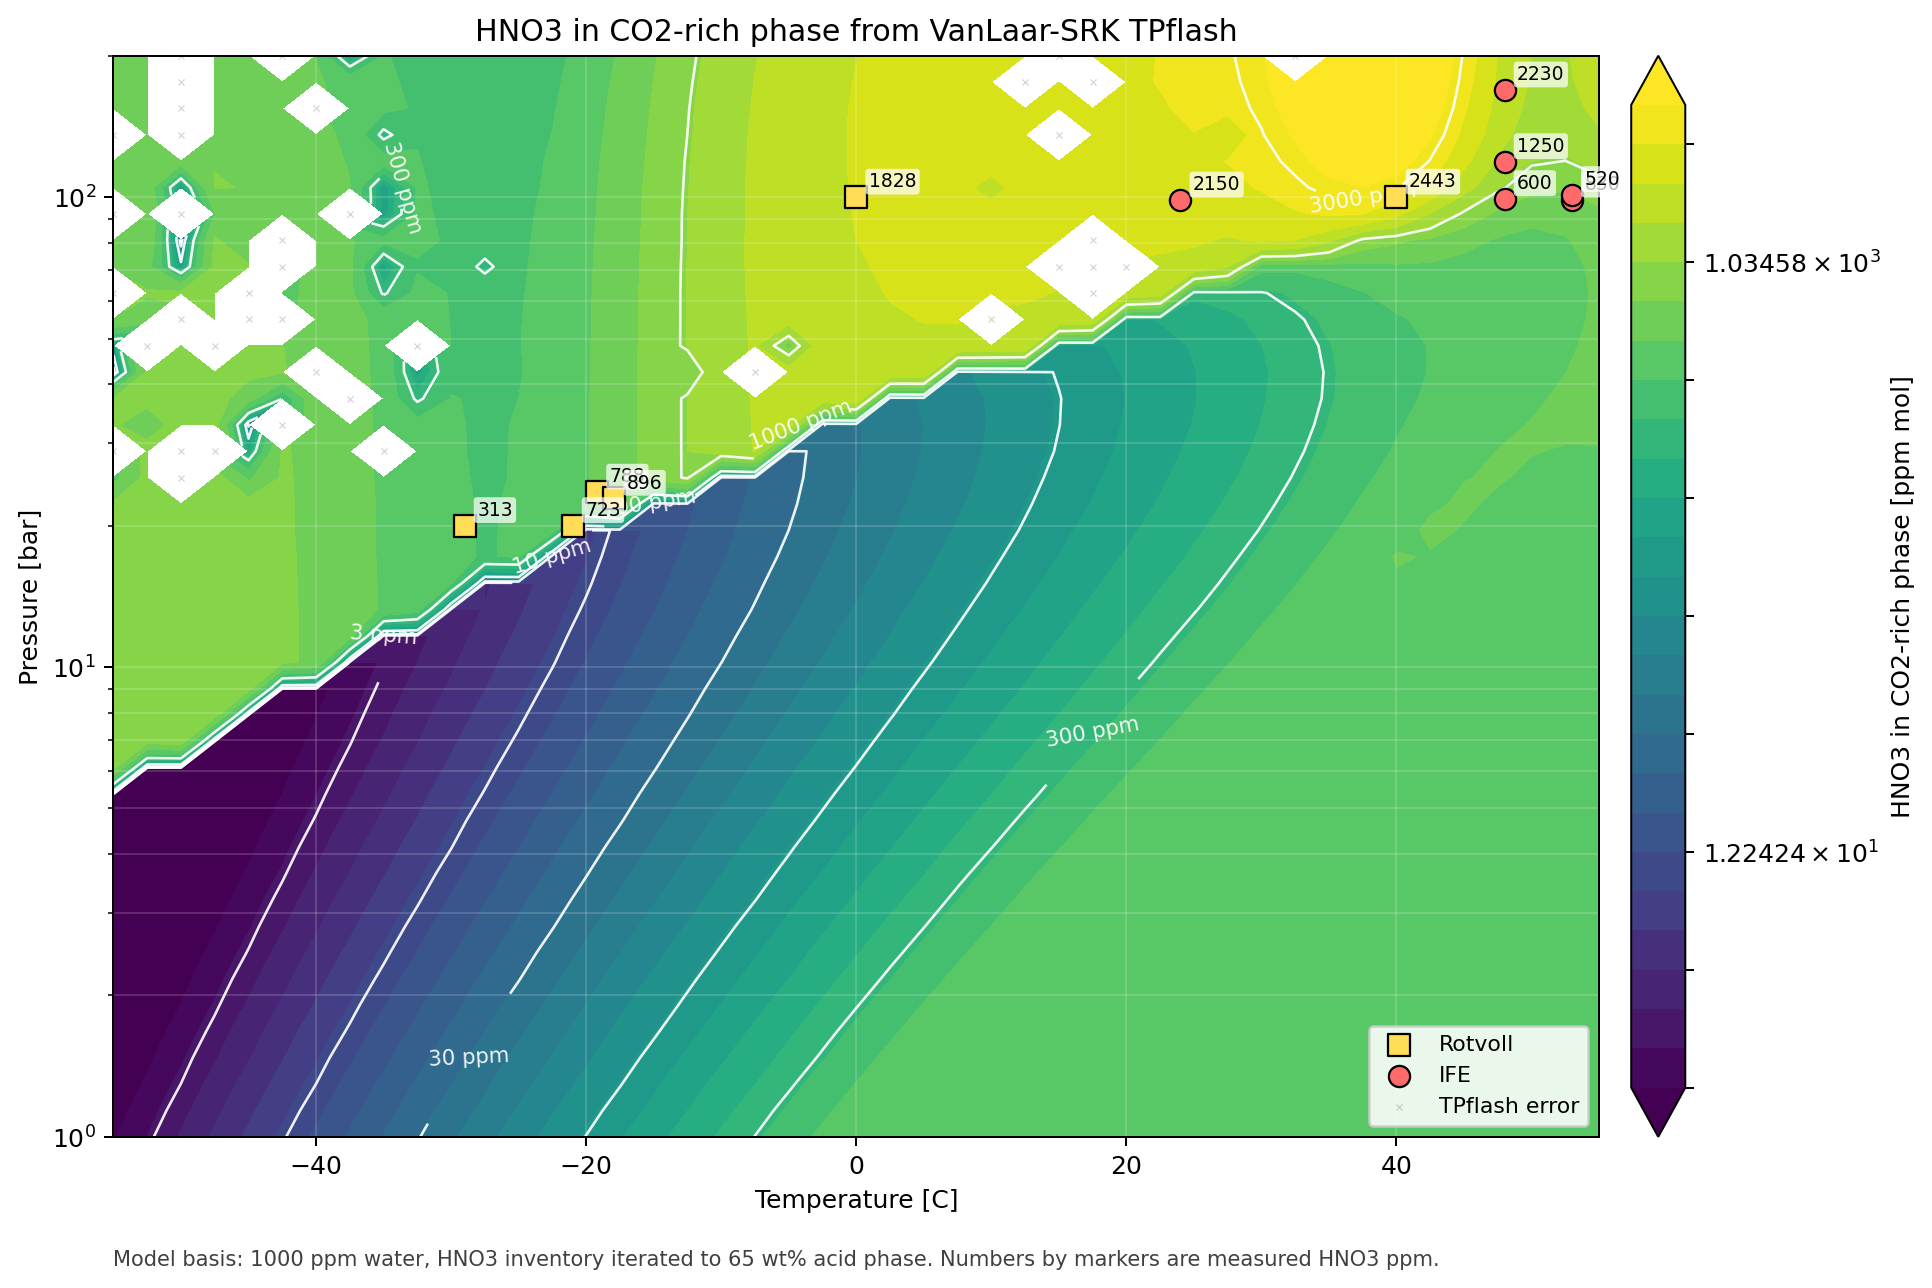

In [ ]:
# HNO3 TPflash solubility map with experiment overlay.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, LogLocator

HNO3_MAP_OUTPUT_PNG = FIGURE_DIR / "tpflash_hno3_solubility_map.png"
HNO3_MAP_PRESSURE_BAR = np.geomspace(1.0, 200.0, 42)
HNO3_MAP_TEMPERATURE_C = np.linspace(-55.0, 55.0, 45)
HNO3_MAP_COLORBAR_TICKS = np.array([1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0])

hno3_map_ppm = np.full((len(HNO3_MAP_TEMPERATURE_C), len(HNO3_MAP_PRESSURE_BAR)), np.nan)
hno3_map_status = np.empty(hno3_map_ppm.shape, dtype=object)
hno3_map_error = np.empty(hno3_map_ppm.shape, dtype=object)
hno3_map_error[:] = ""
hno3_map_error_rows = []

for temperature_index, temperature_c in enumerate(HNO3_MAP_TEMPERATURE_C):
    for pressure_index, pressure_bar in enumerate(HNO3_MAP_PRESSURE_BAR):
        result = run_source_tpflash("nitric acid", temperature_c, pressure_bar)
        hno3_map_ppm[temperature_index, pressure_index] = gas_acid_ppm(result, "nitric acid")
        hno3_map_status[temperature_index, pressure_index] = result.get("status", "OK")
        hno3_map_error[temperature_index, pressure_index] = result.get("error", "")
        if result.get("status", "OK") != "OK":
            hno3_map_error_rows.append({
                "temperature_C": float(temperature_c),
                "pressure_bar": float(pressure_bar),
                "status": result.get("status", "OK"),
                "acid_moles": float(result.get("source_acid_moles", np.nan)),
                "ppm": float(gas_acid_ppm(result, "nitric acid")) if np.isfinite(gas_acid_ppm(result, "nitric acid")) else np.nan,
                "message": result.get("error", ""),
            })

finite_map_values = hno3_map_ppm[np.isfinite(hno3_map_ppm) & (hno3_map_ppm > 0.0)]
if finite_map_values.size == 0:
    raise RuntimeError("No finite HNO3 TPflash map values were generated.")

def fill_missing_log_grid(values, max_passes=120):
    filled_log_values = np.full_like(values, np.nan, dtype=float)
    finite_mask = np.isfinite(values) & (values > 0.0)
    filled_log_values[finite_mask] = np.log10(values[finite_mask])
    for _pass in range(max_passes):
        missing_indices = np.argwhere(~np.isfinite(filled_log_values))
        if missing_indices.size == 0:
            break
        next_values = filled_log_values.copy()
        changed = 0
        for row_index, column_index in missing_indices:
            neighbor_values = []
            for row_offset in [-1, 0, 1]:
                for column_offset in [-1, 0, 1]:
                    if row_offset == 0 and column_offset == 0:
                        continue
                    neighbor_row = row_index + row_offset
                    neighbor_column = column_index + column_offset
                    if 0 <= neighbor_row < values.shape[0] and 0 <= neighbor_column < values.shape[1]:
                        neighbor_value = filled_log_values[neighbor_row, neighbor_column]
                        if np.isfinite(neighbor_value):
                            neighbor_values.append(neighbor_value)
            if neighbor_values:
                next_values[row_index, column_index] = float(np.mean(neighbor_values))
                changed += 1
        filled_log_values = next_values
        if changed == 0:
            break
    remaining_missing = ~np.isfinite(filled_log_values)
    if np.any(remaining_missing):
        filled_log_values[remaining_missing] = float(np.nanmedian(filled_log_values))
    return np.power(10.0, filled_log_values)


def integer_label(value, _position=None):
    if not np.isfinite(value):
        return ""
    rounded_value = int(round(value))
    return f"{rounded_value:,}" if rounded_value >= 1000 else f"{rounded_value}"


def pressure_label(value, _position=None):
    allowed_ticks = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0])
    if np.any(np.isclose(value, allowed_ticks, rtol=0.0, atol=1.0e-9)):
        return integer_label(value)
    return ""


def experiment_label_offset(row):
    source = row["source"]
    temperature_c = row["temperature_c"]
    pressure_bar = row["pressure_bar"]
    ppm = row["ppm"]
    if source == "Ship transport":
        if temperature_c < -25.0:
            return (6, 6)
        if ppm < 750.0:
            return (6, -13)
        if ppm < 850.0:
            return (8, 7)
        return (8, -13)
    if source == "IFE" and temperature_c > 51.0:
        if ppm > 700.0:
            return (-35, -16)
        return (-35, 7)
    if source == "IFE" and temperature_c > 45.0 and pressure_bar < 110.0:
        return (-33, -12)
    if source == "IFE" and temperature_c > 45.0 and pressure_bar < 130.0:
        return (5, 6)
    return (5, 4)


hno3_map_plot_ppm = fill_missing_log_grid(hno3_map_ppm)

plot_min = max(0.3, float(np.nanpercentile(finite_map_values, 5)) * 0.6)
plot_max = min(20000.0, float(np.nanpercentile(finite_map_values, 95)) * 1.6)
if plot_min >= plot_max:
    plot_min = max(0.1, float(np.nanmin(finite_map_values)) * 0.8)
    plot_max = float(np.nanmax(finite_map_values)) * 1.2

filled_levels = np.geomspace(plot_min, plot_max, 30)
colorbar_ticks = HNO3_MAP_COLORBAR_TICKS[(HNO3_MAP_COLORBAR_TICKS >= plot_min) & (HNO3_MAP_COLORBAR_TICKS <= plot_max)]
if colorbar_ticks.size < 4:
    colorbar_ticks = np.geomspace(plot_min, plot_max, 6)

fig, axis = plt.subplots(figsize=(13.0, 7.9))
map_norm = LogNorm(vmin=plot_min, vmax=plot_max)
mesh = axis.contourf(
    HNO3_MAP_TEMPERATURE_C,
    HNO3_MAP_PRESSURE_BAR,
    hno3_map_plot_ppm.T,
    levels=filled_levels,
    norm=map_norm,
    cmap="viridis",
    extend="both",
)

experiment_groups = [
    ("Rotvoll / ship transport", [row for row in HNO3_EXPERIMENTS if row["source"] in ["Rotvoll", "Ship transport"]], "s"),
    ("IFE", [row for row in HNO3_EXPERIMENTS if row["source"] == "IFE"], "o"),
]
for source_label, rows, marker in experiment_groups:
    if not rows:
        continue
    axis.scatter(
        [row["temperature_c"] for row in rows],
        [row["pressure_bar"] for row in rows],
        c=[row["ppm"] for row in rows],
        cmap=mesh.cmap,
        norm=map_norm,
        s=82 if marker == "o" else 88,
        marker=marker,
        edgecolors="black",
        linewidths=1.75,
        zorder=5,
        label=source_label,
    )
    for row in rows:
        axis.annotate(
            integer_label(row["ppm"]),
            (row["temperature_c"], row["pressure_bar"]),
            xytext=experiment_label_offset(row),
            textcoords="offset points",
            fontsize=7.4,
            fontweight="bold",
            color="black",
            bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "edgecolor": "black", "linewidth": 0.35, "alpha": 0.78},
            zorder=6,
        )

error_points = np.argwhere(hno3_map_status == "ERROR")
if error_points.size > 0:
    axis.contourf(
        HNO3_MAP_TEMPERATURE_C,
        HNO3_MAP_PRESSURE_BAR,
        (hno3_map_status.T == "ERROR"),
        levels=[0.5, 1.5],
        colors=["white"],
        alpha=0.34,
        antialiased=True,
    )
    axis.scatter(
        [HNO3_MAP_TEMPERATURE_C[item[0]] for item in error_points],
        [HNO3_MAP_PRESSURE_BAR[item[1]] for item in error_points],
        s=8,
        marker="x",
        color="black",
        alpha=0.32,
        linewidths=0.65,
        label="TPflash error",
    )

axis.set_yscale("log")
axis.set_xlim(-55.0, 55.0)
axis.set_ylim(1.0, 200.0)
axis.set_xlabel("Temperature [C]")
axis.set_ylabel("Pressure [bar]")
axis.set_title("HNO3 in CO2-rich phase from VanLaar-SRK TPflash")
axis.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
axis.yaxis.set_major_formatter(FuncFormatter(pressure_label))
axis.grid(True, which="major", color="white", alpha=0.22, linewidth=0.7)
axis.grid(True, which="minor", color="white", alpha=0.08, linewidth=0.45)
axis.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=8.8)
colorbar = fig.colorbar(mesh, ax=axis, pad=0.018, ticks=colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(integer_label))
colorbar.set_label("HNO3 in CO2-rich phase [ppm mol]")
fig.text(
    0.125,
    0.018,
    "Model basis: 1000 ppm water, HNO3 inventory iterated to 65 wt% acid phase. Experiment markers use the same ppm color scale.",
    fontsize=8.4,
    color="0.25",
)
fig.savefig(HNO3_MAP_OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.close(fig)

import csv
HNO3_MAP_ERROR_CSV = FIGURE_DIR / "tpflash_hno3_solubility_map_errors.csv"
with open(HNO3_MAP_ERROR_CSV, "w", newline="") as error_file:
    writer = csv.DictWriter(error_file, fieldnames=["temperature_C", "pressure_bar", "status", "acid_moles", "ppm", "message"])
    writer.writeheader()
    writer.writerows(hno3_map_error_rows)

print(f"Saved {HNO3_MAP_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
print(f"TPflash map errors: {int(np.sum(hno3_map_status == 'ERROR'))} of {hno3_map_status.size} points")
print(f"Saved {HNO3_MAP_ERROR_CSV.relative_to(PROJECT_ROOT)} with {len(hno3_map_error_rows)} error rows")
display(Image(filename=str(HNO3_MAP_OUTPUT_PNG)))


In [ ]:
# Water TPflash solubility map with Rotvoll water experiment overlay only.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, LogLocator

WATER_MAP_OUTPUT_PNG = FIGURE_DIR / "tpflash_water_solubility_map.png"
WATER_MAP_ERROR_CSV = FIGURE_DIR / "tpflash_water_solubility_map_errors.csv"
WATER_MAP_COLORBAR_TICKS = np.array([1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0])
WATER_EXPERIMENTS = [
    {"source": "Rotvoll water", "pressure_bar": 20.0, "temperature_c": -21.0, "ppm": 1300.0},
    {"source": "Rotvoll water", "pressure_bar": 20.0, "temperature_c": -29.0, "ppm": 1083.0},
    {"source": "Rotvoll water", "pressure_bar": 23.56, "temperature_c": -19.19, "ppm": 723.0},
    {"source": "Rotvoll water", "pressure_bar": 22.86, "temperature_c": -17.92, "ppm": 759.0},
]

water_map_ppm = np.full((len(HNO3_MAP_TEMPERATURE_C), len(HNO3_MAP_PRESSURE_BAR)), np.nan)
water_map_status = np.empty(water_map_ppm.shape, dtype=object)
water_map_error = np.empty(water_map_ppm.shape, dtype=object)
water_map_error[:] = ""
water_map_error_rows = []

for temperature_index, temperature_c in enumerate(HNO3_MAP_TEMPERATURE_C):
    for pressure_index, pressure_bar in enumerate(HNO3_MAP_PRESSURE_BAR):
        result = run_source_tpflash("nitric acid", temperature_c, pressure_bar)
        water_map_ppm[temperature_index, pressure_index] = result.get("gas_water_ppm", np.nan)
        water_map_status[temperature_index, pressure_index] = result.get("status", "OK")
        water_map_error[temperature_index, pressure_index] = result.get("error", "")
        if result.get("status", "OK") != "OK":
            water_map_error_rows.append({
                "temperature_C": float(temperature_c),
                "pressure_bar": float(pressure_bar),
                "status": result.get("status", "OK"),
                "acid_moles": float(result.get("source_acid_moles", np.nan)),
                "ppm": float(result.get("gas_water_ppm", np.nan)) if np.isfinite(result.get("gas_water_ppm", np.nan)) else np.nan,
                "message": result.get("error", ""),
            })

finite_water_values = water_map_ppm[np.isfinite(water_map_ppm) & (water_map_ppm > 0.0)]
if finite_water_values.size == 0:
    raise RuntimeError("No finite water TPflash map values were generated.")

water_map_plot_ppm = fill_missing_log_grid(water_map_ppm)

water_plot_min = max(0.3, min(float(np.nanpercentile(finite_water_values, 5)) * 0.6, min(row["ppm"] for row in WATER_EXPERIMENTS) * 0.8))
water_plot_max = min(20000.0, max(float(np.nanpercentile(finite_water_values, 95)) * 1.6, max(row["ppm"] for row in WATER_EXPERIMENTS) * 1.2))
if water_plot_min >= water_plot_max:
    water_plot_min = max(0.1, float(np.nanmin(finite_water_values)) * 0.8)
    water_plot_max = float(np.nanmax(finite_water_values)) * 1.2

water_filled_levels = np.geomspace(water_plot_min, water_plot_max, 30)
water_colorbar_ticks = WATER_MAP_COLORBAR_TICKS[(WATER_MAP_COLORBAR_TICKS >= water_plot_min) & (WATER_MAP_COLORBAR_TICKS <= water_plot_max)]
if water_colorbar_ticks.size < 4:
    water_colorbar_ticks = np.geomspace(water_plot_min, water_plot_max, 6)


def water_experiment_label_offset(row):
    temperature_c = row["temperature_c"]
    ppm = row["ppm"]
    if temperature_c < -25.0:
        return (7, 7)
    if ppm >= 1000.0:
        return (7, -14)
    if ppm < 750.0:
        return (8, 7)
    return (8, -13)


fig, axis = plt.subplots(figsize=(13.0, 7.9))
water_norm = LogNorm(vmin=water_plot_min, vmax=water_plot_max)
mesh = axis.contourf(
    HNO3_MAP_TEMPERATURE_C,
    HNO3_MAP_PRESSURE_BAR,
    water_map_plot_ppm.T,
    levels=water_filled_levels,
    norm=water_norm,
    cmap="viridis",
    extend="both",
)

axis.scatter(
    [row["temperature_c"] for row in WATER_EXPERIMENTS],
    [row["pressure_bar"] for row in WATER_EXPERIMENTS],
    c=[row["ppm"] for row in WATER_EXPERIMENTS],
    cmap=mesh.cmap,
    norm=water_norm,
    s=96,
    marker="s",
    edgecolors="black",
    linewidths=1.9,
    zorder=5,
    label="Rotvoll water exp.",
)
for row in WATER_EXPERIMENTS:
    axis.annotate(
        integer_label(row["ppm"]),
        (row["temperature_c"], row["pressure_bar"]),
        xytext=water_experiment_label_offset(row),
        textcoords="offset points",
        fontsize=7.5,
        fontweight="bold",
        color="black",
        bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "edgecolor": "black", "linewidth": 0.35, "alpha": 0.78},
        zorder=6,
    )

water_error_points = np.argwhere(water_map_status == "ERROR")
if water_error_points.size > 0:
    axis.contourf(
        HNO3_MAP_TEMPERATURE_C,
        HNO3_MAP_PRESSURE_BAR,
        (water_map_status.T == "ERROR"),
        levels=[0.5, 1.5],
        colors=["white"],
        alpha=0.34,
        antialiased=True,
    )
    axis.scatter(
        [HNO3_MAP_TEMPERATURE_C[item[0]] for item in water_error_points],
        [HNO3_MAP_PRESSURE_BAR[item[1]] for item in water_error_points],
        s=8,
        marker="x",
        color="black",
        alpha=0.32,
        linewidths=0.65,
        label="TPflash error",
    )

axis.set_yscale("log")
axis.set_xlim(-55.0, 55.0)
axis.set_ylim(1.0, 200.0)
axis.set_xlabel("Temperature [C]")
axis.set_ylabel("Pressure [bar]")
axis.set_title("Water in CO2-rich phase from VanLaar-SRK TPflash")
axis.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
axis.yaxis.set_major_formatter(FuncFormatter(pressure_label))
axis.grid(True, which="major", color="white", alpha=0.22, linewidth=0.7)
axis.grid(True, which="minor", color="white", alpha=0.08, linewidth=0.45)
axis.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=8.8)
colorbar = fig.colorbar(mesh, ax=axis, pad=0.018, ticks=water_colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(integer_label))
colorbar.set_label("Water in CO2-rich phase [ppm mol]")
fig.text(
    0.125,
    0.018,
    "Model basis: 1000 ppm water, HNO3 inventory iterated to 65 wt% acid phase. Only Rotvoll water experiments are overlaid; IFE did not measure water for this case.",
    fontsize=8.4,
    color="0.25",
)
fig.savefig(WATER_MAP_OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.close(fig)

import csv
with open(WATER_MAP_ERROR_CSV, "w", newline="") as error_file:
    writer = csv.DictWriter(error_file, fieldnames=["temperature_C", "pressure_bar", "status", "acid_moles", "ppm", "message"])
    writer.writeheader()
    writer.writerows(water_map_error_rows)

print(f"Saved {WATER_MAP_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
print(f"TPflash water map errors: {int(np.sum(water_map_status == 'ERROR'))} of {water_map_status.size} points")
print(f"Saved {WATER_MAP_ERROR_CSV.relative_to(PROJECT_ROOT)} with {len(water_map_error_rows)} error rows")
display(Image(filename=str(WATER_MAP_OUTPUT_PNG)))


In [ ]:
# 100 wt% HNO3 binary TPflash map: material CO2 + dry acid only.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, LogLocator

PURE_ACID_MAP_OUTPUT_PNG = FIGURE_DIR / "tpflash_hno3_100pct_acid_map.png"
PURE_ACID_MAP_ERROR_CSV = FIGURE_DIR / "tpflash_hno3_100pct_acid_map_errors.csv"
PURE_ACID_SOURCE_MOLES = CO2_MOLES
PURE_ACID_BETA_THRESHOLD = 1.0e-9
PURE_ACID_COLORBAR_TICKS = np.array([1000.0, 3000.0, 10000.0, 30000.0, 100000.0, 300000.0, 600000.0])

if "HNO3_MAP_PRESSURE_BAR" not in globals():
    HNO3_MAP_PRESSURE_BAR = np.geomspace(1.0, 200.0, 42)
if "HNO3_MAP_TEMPERATURE_C" not in globals():
    HNO3_MAP_TEMPERATURE_C = np.linspace(-55.0, 55.0, 45)
if "fill_missing_log_grid" not in globals():
    def fill_missing_log_grid(values, max_passes=120):
        filled_log_values = np.full_like(values, np.nan, dtype=float)
        finite_mask = np.isfinite(values) & (values > 0.0)
        filled_log_values[finite_mask] = np.log10(values[finite_mask])
        for _pass in range(max_passes):
            missing_indices = np.argwhere(~np.isfinite(filled_log_values))
            if missing_indices.size == 0:
                break
            next_values = filled_log_values.copy()
            changed = 0
            for row_index, column_index in missing_indices:
                neighbor_values = []
                for row_offset in [-1, 0, 1]:
                    for column_offset in [-1, 0, 1]:
                        if row_offset == 0 and column_offset == 0:
                            continue
                        neighbor_row = row_index + row_offset
                        neighbor_column = column_index + column_offset
                        if 0 <= neighbor_row < values.shape[0] and 0 <= neighbor_column < values.shape[1]:
                            neighbor_value = filled_log_values[neighbor_row, neighbor_column]
                            if np.isfinite(neighbor_value):
                                neighbor_values.append(neighbor_value)
                if neighbor_values:
                    next_values[row_index, column_index] = float(np.mean(neighbor_values))
                    changed += 1
            filled_log_values = next_values
            if changed == 0:
                break
        remaining_missing = ~np.isfinite(filled_log_values)
        if np.any(remaining_missing):
            filled_log_values[remaining_missing] = float(np.nanmedian(filled_log_values))
        return np.power(10.0, filled_log_values)
if "integer_label" not in globals():
    def integer_label(value, _position=None):
        if not np.isfinite(value):
            return ""
        rounded_value = int(round(value))
        return f"{rounded_value:,}" if rounded_value >= 1000 else f"{rounded_value}"
if "pressure_label" not in globals():
    def pressure_label(value, _position=None):
        allowed_ticks = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0])
        if np.any(np.isclose(value, allowed_ticks, rtol=0.0, atol=1.0e-9)):
            return integer_label(value)
        return ""

pure_acid_map_ppm = np.full((len(HNO3_MAP_TEMPERATURE_C), len(HNO3_MAP_PRESSURE_BAR)), np.nan)
pure_acid_map_beta = np.full_like(pure_acid_map_ppm, np.nan, dtype=float)
pure_acid_map_status = np.empty(pure_acid_map_ppm.shape, dtype=object)
pure_acid_map_error = np.empty(pure_acid_map_ppm.shape, dtype=object)
pure_acid_map_error[:] = ""
pure_acid_map_error_rows = []

for temperature_index, temperature_c in enumerate(HNO3_MAP_TEMPERATURE_C):
    for pressure_index, pressure_bar in enumerate(HNO3_MAP_PRESSURE_BAR):
        result = safe_run_vanlaar_tpflash(
            temperature_c,
            pressure_bar,
            water_moles=TRACE_MOLES,
            nitric_acid_moles=PURE_ACID_SOURCE_MOLES,
            sulfuric_acid_moles=TRACE_MOLES,
        )
        pure_acid_map_ppm[temperature_index, pressure_index] = gas_acid_ppm(result, "nitric acid")
        pure_acid_map_beta[temperature_index, pressure_index] = result.get("aqueous_beta", np.nan)
        pure_acid_map_status[temperature_index, pressure_index] = result.get("status", "OK")
        pure_acid_map_error[temperature_index, pressure_index] = result.get("error", "")
        if result.get("status", "OK") != "OK":
            pure_acid_map_error_rows.append({
                "temperature_C": float(temperature_c),
                "pressure_bar": float(pressure_bar),
                "status": result.get("status", "OK"),
                "acid_moles": float(PURE_ACID_SOURCE_MOLES),
                "ppm": float(gas_acid_ppm(result, "nitric acid")) if np.isfinite(gas_acid_ppm(result, "nitric acid")) else np.nan,
                "message": result.get("error", ""),
            })

finite_pure_acid_values = pure_acid_map_ppm[np.isfinite(pure_acid_map_ppm) & (pure_acid_map_ppm > 0.0)]
if finite_pure_acid_values.size == 0:
    raise RuntimeError("No finite 100 wt% HNO3 TPflash map values were generated.")

pure_acid_map_plot_ppm = fill_missing_log_grid(pure_acid_map_ppm)
pure_acid_two_phase_mask = (pure_acid_map_beta > PURE_ACID_BETA_THRESHOLD) & (pure_acid_map_status == "OK")
pure_acid_single_phase_mask = (~pure_acid_two_phase_mask) & (pure_acid_map_status == "OK")

pure_acid_plot_min = max(300.0, float(np.nanpercentile(finite_pure_acid_values, 2)) * 0.75)
pure_acid_plot_max = min(800000.0, float(np.nanpercentile(finite_pure_acid_values, 98)) * 1.15)
if pure_acid_plot_min >= pure_acid_plot_max:
    pure_acid_plot_min = max(1.0, float(np.nanmin(finite_pure_acid_values)) * 0.8)
    pure_acid_plot_max = float(np.nanmax(finite_pure_acid_values)) * 1.2
pure_acid_levels = np.geomspace(pure_acid_plot_min, pure_acid_plot_max, 36)
pure_acid_colorbar_ticks = PURE_ACID_COLORBAR_TICKS[(PURE_ACID_COLORBAR_TICKS >= pure_acid_plot_min) & (PURE_ACID_COLORBAR_TICKS <= pure_acid_plot_max)]
if pure_acid_colorbar_ticks.size < 4:
    pure_acid_colorbar_ticks = np.geomspace(pure_acid_plot_min, pure_acid_plot_max, 6)

fig, axis = plt.subplots(figsize=(13.0, 7.9))
pure_acid_norm = LogNorm(vmin=pure_acid_plot_min, vmax=pure_acid_plot_max)
mesh = axis.contourf(
    HNO3_MAP_TEMPERATURE_C,
    HNO3_MAP_PRESSURE_BAR,
    pure_acid_map_plot_ppm.T,
    levels=pure_acid_levels,
    norm=pure_acid_norm,
    cmap="magma",
    extend="both",
)

if np.any(pure_acid_single_phase_mask):
    axis.contourf(
        HNO3_MAP_TEMPERATURE_C,
        HNO3_MAP_PRESSURE_BAR,
        pure_acid_single_phase_mask.T,
        levels=[0.5, 1.5],
        colors=["white"],
        alpha=0.12,
        antialiased=True,
    )
if np.any(pure_acid_two_phase_mask):
    axis.contour(
        HNO3_MAP_TEMPERATURE_C,
        HNO3_MAP_PRESSURE_BAR,
        pure_acid_two_phase_mask.T.astype(float),
        levels=[0.5],
        colors="black",
        linewidths=0.95,
        alpha=0.72,
    )

axis.set_yscale("log")
axis.set_xlim(-55.0, 55.0)
axis.set_ylim(1.0, 200.0)
axis.set_xlabel("Temperature [C]")
axis.set_ylabel("Pressure [bar]")
axis.set_title("HNO3 in CO2-rich phase from dry CO2 + 100 wt% acid TPflash")
axis.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
axis.yaxis.set_major_formatter(FuncFormatter(pressure_label))
axis.grid(True, which="major", color="white", alpha=0.20, linewidth=0.7)
axis.grid(True, which="minor", color="white", alpha=0.08, linewidth=0.45)
colorbar = fig.colorbar(mesh, ax=axis, pad=0.018, ticks=pure_acid_colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(integer_label))
colorbar.set_label("HNO3 in CO2-rich phase [ppm mol]")
fig.text(
    0.125,
    0.018,
    "Binary model basis: 1e6 mol CO2 + 1e6 mol HNO3; water and H2SO4 are trace placeholders only. Pale area is single-phase/feed-limited; black line marks dry acid-phase onset.",
    fontsize=8.4,
    color="0.25",
)
fig.savefig(PURE_ACID_MAP_OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.close(fig)

import csv
with open(PURE_ACID_MAP_ERROR_CSV, "w", newline="") as error_file:
    writer = csv.DictWriter(error_file, fieldnames=["temperature_C", "pressure_bar", "status", "acid_moles", "ppm", "message"])
    writer.writeheader()
    writer.writerows(pure_acid_map_error_rows)

print(f"Saved {PURE_ACID_MAP_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
print(f"TPflash 100 wt% acid map errors: {int(np.sum(pure_acid_map_status == 'ERROR'))} of {pure_acid_map_status.size} points")
print(f"Saved {PURE_ACID_MAP_ERROR_CSV.relative_to(PROJECT_ROOT)} with {len(pure_acid_map_error_rows)} error rows")
display(Image(filename=str(PURE_ACID_MAP_OUTPUT_PNG)))

## TPflash Target Modes

The 65 wt% HNO3 / 98 wt% H2SO4 source-strength calculation and the experiment comparison are different finite-inventory TPflash targets. Holding the aqueous phase at a specified acid strength with only 1000 ppm water can require a large acid inventory, which may drive high acid concentration in the CO2-rich phase. The cell below uses the same 1000 ppm water basis but instead iterates acid inventory to match the measured gas-phase ppm, then reports the aqueous acid strength that TPflash predicts.

In [ ]:
# Water TPflash solubility map with Rotvoll water experiment overlay only.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, LogLocator

WATER_MAP_OUTPUT_PNG = FIGURE_DIR / "tpflash_water_solubility_map.png"
WATER_MAP_ERROR_CSV = FIGURE_DIR / "tpflash_water_solubility_map_errors.csv"
WATER_MAP_COLORBAR_TICKS = np.array([1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0])
WATER_EXPERIMENTS = [
    {"source": "Rotvoll water", "pressure_bar": 100.0, "temperature_c": 40.0, "ppm": 1300.0},
    {"source": "Rotvoll water", "pressure_bar": 100.0, "temperature_c": 0.0, "ppm": 1083.0},
    {"source": "Rotvoll water", "pressure_bar": 22.3, "temperature_c": -21.0, "ppm": 723.0},
    {"source": "Rotvoll water", "pressure_bar": 20.0, "temperature_c": -29.0, "ppm": 759.0},
]

water_map_ppm = np.full((len(HNO3_MAP_TEMPERATURE_C), len(HNO3_MAP_PRESSURE_BAR)), np.nan)
water_map_status = np.empty(water_map_ppm.shape, dtype=object)
water_map_error = np.empty(water_map_ppm.shape, dtype=object)
water_map_error[:] = ""
water_map_error_rows = []

for temperature_index, temperature_c in enumerate(HNO3_MAP_TEMPERATURE_C):
    for pressure_index, pressure_bar in enumerate(HNO3_MAP_PRESSURE_BAR):
        result = run_source_tpflash("nitric acid", temperature_c, pressure_bar)
        water_map_ppm[temperature_index, pressure_index] = result.get("gas_water_ppm", np.nan)
        water_map_status[temperature_index, pressure_index] = result.get("status", "OK")
        water_map_error[temperature_index, pressure_index] = result.get("error", "")
        if result.get("status", "OK") != "OK":
            water_map_error_rows.append({
                "temperature_C": float(temperature_c),
                "pressure_bar": float(pressure_bar),
                "status": result.get("status", "OK"),
                "acid_moles": float(result.get("source_acid_moles", np.nan)),
                "ppm": float(result.get("gas_water_ppm", np.nan)) if np.isfinite(result.get("gas_water_ppm", np.nan)) else np.nan,
                "message": result.get("error", ""),
            })

finite_water_values = water_map_ppm[np.isfinite(water_map_ppm) & (water_map_ppm > 0.0)]
if finite_water_values.size == 0:
    raise RuntimeError("No finite water TPflash map values were generated.")

water_map_plot_ppm = fill_missing_log_grid(water_map_ppm)

water_plot_min = max(0.3, min(float(np.nanpercentile(finite_water_values, 5)) * 0.6, min(row["ppm"] for row in WATER_EXPERIMENTS) * 0.8))
water_plot_max = min(20000.0, max(float(np.nanpercentile(finite_water_values, 95)) * 1.6, max(row["ppm"] for row in WATER_EXPERIMENTS) * 1.2))
if water_plot_min >= water_plot_max:
    water_plot_min = max(0.1, float(np.nanmin(finite_water_values)) * 0.8)
    water_plot_max = float(np.nanmax(finite_water_values)) * 1.2

water_filled_levels = np.geomspace(water_plot_min, water_plot_max, 30)
water_colorbar_ticks = WATER_MAP_COLORBAR_TICKS[(WATER_MAP_COLORBAR_TICKS >= water_plot_min) & (WATER_MAP_COLORBAR_TICKS <= water_plot_max)]
if water_colorbar_ticks.size < 4:
    water_colorbar_ticks = np.geomspace(water_plot_min, water_plot_max, 6)


def water_experiment_label_offset(row):
    temperature_c = row["temperature_c"]
    pressure_bar = row["pressure_bar"]
    ppm = row["ppm"]
    if pressure_bar > 80.0 and temperature_c > 20.0:
        return (7, -14)
    if pressure_bar > 80.0:
        return (7, 7)
    if temperature_c < -25.0:
        return (7, 7)
    if ppm < 750.0:
        return (8, -13)
    return (8, 7)


fig, axis = plt.subplots(figsize=(13.0, 7.9))
water_norm = LogNorm(vmin=water_plot_min, vmax=water_plot_max)
mesh = axis.contourf(
    HNO3_MAP_TEMPERATURE_C,
    HNO3_MAP_PRESSURE_BAR,
    water_map_plot_ppm.T,
    levels=water_filled_levels,
    norm=water_norm,
    cmap="viridis",
    extend="both",
)

axis.scatter(
    [row["temperature_c"] for row in WATER_EXPERIMENTS],
    [row["pressure_bar"] for row in WATER_EXPERIMENTS],
    c=[row["ppm"] for row in WATER_EXPERIMENTS],
    cmap=mesh.cmap,
    norm=water_norm,
    s=96,
    marker="s",
    edgecolors="black",
    linewidths=1.9,
    zorder=5,
    label="Rotvoll water exp.",
)
for row in WATER_EXPERIMENTS:
    axis.annotate(
        integer_label(row["ppm"]),
        (row["temperature_c"], row["pressure_bar"]),
        xytext=water_experiment_label_offset(row),
        textcoords="offset points",
        fontsize=7.5,
        fontweight="bold",
        color="black",
        bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "edgecolor": "black", "linewidth": 0.35, "alpha": 0.78},
        zorder=6,
    )

water_error_points = np.argwhere(water_map_status == "ERROR")
if water_error_points.size > 0:
    axis.contourf(
        HNO3_MAP_TEMPERATURE_C,
        HNO3_MAP_PRESSURE_BAR,
        (water_map_status.T == "ERROR"),
        levels=[0.5, 1.5],
        colors=["white"],
        alpha=0.34,
        antialiased=True,
    )
    axis.scatter(
        [HNO3_MAP_TEMPERATURE_C[item[0]] for item in water_error_points],
        [HNO3_MAP_PRESSURE_BAR[item[1]] for item in water_error_points],
        s=8,
        marker="x",
        color="black",
        alpha=0.32,
        linewidths=0.65,
        label="TPflash error",
    )

axis.set_yscale("log")
axis.set_xlim(-55.0, 55.0)
axis.set_ylim(1.0, 200.0)
axis.set_xlabel("Temperature [C]")
axis.set_ylabel("Pressure [bar]")
axis.set_title("Water in CO2-rich phase from VanLaar-SRK TPflash")
axis.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 2.0, 5.0)))
axis.yaxis.set_major_formatter(FuncFormatter(pressure_label))
axis.grid(True, which="major", color="white", alpha=0.22, linewidth=0.7)
axis.grid(True, which="minor", color="white", alpha=0.08, linewidth=0.45)
axis.legend(loc="lower right", frameon=True, framealpha=0.9, fontsize=8.8)
colorbar = fig.colorbar(mesh, ax=axis, pad=0.018, ticks=water_colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(integer_label))
colorbar.set_label("Water in CO2-rich phase [ppm mol]")
fig.text(
    0.125,
    0.018,
    "Model basis: 1000 ppm water, HNO3 inventory iterated to 65 wt% acid phase. Only Rotvoll water experiments are overlaid; IFE did not measure water for this case.",
    fontsize=8.4,
    color="0.25",
)
fig.savefig(WATER_MAP_OUTPUT_PNG, dpi=180, bbox_inches="tight")
plt.close(fig)

import csv
with open(WATER_MAP_ERROR_CSV, "w", newline="") as error_file:
    writer = csv.DictWriter(error_file, fieldnames=["temperature_C", "pressure_bar", "status", "acid_moles", "ppm", "message"])
    writer.writeheader()
    writer.writerows(water_map_error_rows)

print(f"Saved {WATER_MAP_OUTPUT_PNG.relative_to(PROJECT_ROOT)}")
print(f"TPflash water map errors: {int(np.sum(water_map_status == 'ERROR'))} of {water_map_status.size} points")
print(f"Saved {WATER_MAP_ERROR_CSV.relative_to(PROJECT_ROOT)} with {len(water_map_error_rows)} error rows")
display(Image(filename=str(WATER_MAP_OUTPUT_PNG)))

## Discussion and report notes

The new TPflash-only study section is designed to answer the corrosion question from the flash results rather than from a separate static solubility helper.

**HNO3 versus H2SO4.** HNO3 is much more soluble in CO2-rich phases than H2SO4 in this VanLaar-SRK model. In mixed-acid cases, HNO3 can increase the amount of acid-water liquid and change the composition of that liquid, but it does not make H2SO4 behave like a volatile acid. H2SO4 mostly partitions to the aqueous acid phase when a liquid phase exists.

**Water below 30 ppm.** Drying the CO2 lowers the available liquid inventory, but the remaining liquid can become more concentrated in H2SO4. That is important for corrosion: reducing water can reduce the amount of corrosive liquid, but if any acid-water liquid remains, the acid strength can increase. The notebook therefore plots gas water ppm, gas H2SO4 ppm, aqueous beta, and aqueous H2SO4 wt% together.

**Recommended acceptance view.** Use a combined criterion rather than a water-only limit: low aqueous beta, low H2SO4 wt% in any aqueous phase, and low gas-phase acid ppm. A useful next plot is a P-T risk map with contours of aqueous beta and H2SO4 wt% at the expected acid inventory, plus a sensitivity plot for acid inventory uncertainty.